# IEEE-CIS Fraud Detection: EDA and Feature Engineering

The objective of this notebook is to understand transaction-level fraud patterns in the IEEE-CIS Fraud Detection dataset and prepare meaningful features for machine learning models.

This notebook focuses on:
- Understanding the transaction and identity datasets
- Analyzing fraud imbalance
- Exploring transaction, card, email, device, address, and anonymous feature groups
- Performing statistical analysis
- Creating engineered features for downstream modeling

## Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
# from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

## Dataset Loading

The dataset contains two main files for training:
- `train_transaction.csv`: transaction-level features
- `train_identity.csv`: identity/device-related features

These files are merged using `TransactionID`, which uniquely connects transaction records with available identity information.

In [10]:
train_transaction = pd.read_csv("../data/train_transaction.csv")
train_identity = pd.read_csv("../data/train_identity.csv")

test_transaction = pd.read_csv("../data/test_transaction.csv")
test_identity = pd.read_csv("../data/test_identity.csv")

In [11]:
train_transaction.shape

(590540, 394)

In [12]:
train_identity.shape

(144233, 41)

In [13]:
test_transaction.shape

(506691, 393)

In [14]:
test_identity.shape

(141907, 41)

In [15]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## Merge Dataset

In [17]:
train=train_transaction.merge(train_identity, on='TransactionID', how='left')
test=test_transaction.merge(test_identity, on='TransactionID', how='left')

In [18]:
train.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

In [19]:
test.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=433)

## Target Distribution

The target variable is `isFraud`, where:

- `0` = Non-fraud transaction
- `1` = Fraud transaction

The dataset is highly imbalanced. Fraud transactions represent only about 3.5% of the overall dataset. Because of this imbalance, accuracy alone is not a reliable evaluation metric for modeling. Metrics such as precision, recall, F1-score, and ROC-AUC are more meaningful for fraud detection.

In [20]:
target_count=train['isFraud'].value_counts()
target_count

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [21]:
target_percent=train['isFraud'].value_counts(normalize=True)*100
target_percent

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

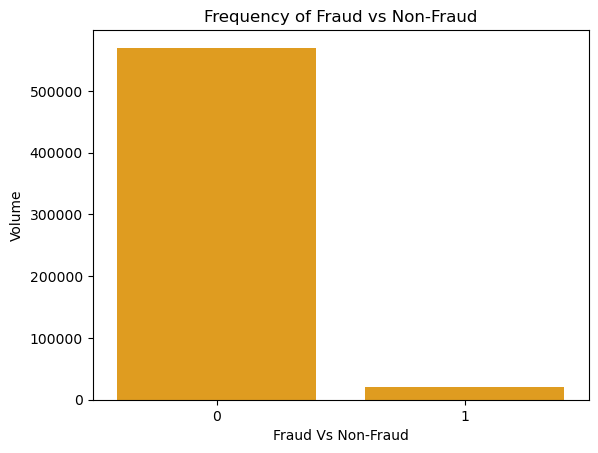

In [22]:
sns.countplot(data=train, x='isFraud',color='Orange')
plt.title('Frequency of Fraud vs Non-Fraud')
plt.xlabel('Fraud Vs Non-Fraud')
plt.ylabel('Volume')
plt.show()

Data set is hightly imbalanced. Fruad transaction are only a small population of oveall transaction that is 3%.

## Missing Value Analysis

Many features contain missing values, especially identity, distance, and device-related fields. In fraud detection, missingness itself can be informative because fraud patterns may involve incomplete or unavailable identity/device information.

Therefore, high-missing columns are not immediately dropped during EDA. Instead, missingness is analyzed first and later handled through imputation or missing-value indicator features during feature engineering.

In [23]:
missing=train.isnull().mean().sort_values(ascending=False)*100
missing_df=missing.reset_index()
missing_df.columns=['features','missing_percent']
missing_df.head(25)

,features,missing_percent
0,id_24,99.196159
1,id_25,99.130965
2,id_07,99.127070
3,id_08,99.127070
4,id_21,99.126393
5,id_26,99.125715
6,id_27,99.124699
7,id_23,99.124699
8,id_22,99.124699
9,dist2,93.628374


Text(0.5, 1.0, 'Distribution of Missing Value Across Features')

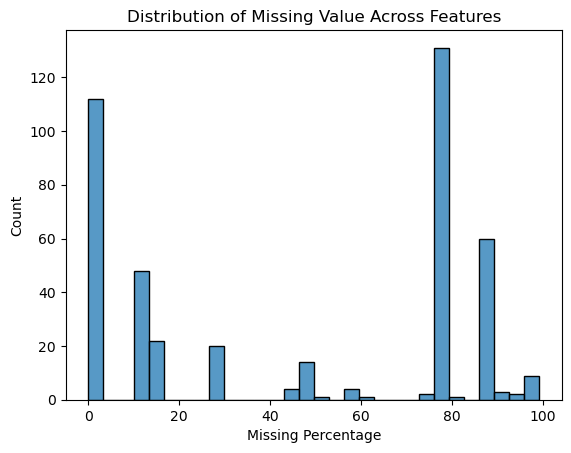

In [24]:
# plt.figure(figsize=(10,8))
sns.histplot(missing_df['missing_percent'],bins=30)
plt.xlabel('Missing Percentage')
plt.title('Distribution of Missing Value Across Features')

In [25]:
high_missing_col=missing_df[missing_df['missing_percent']>=90]['features'].to_list()
print(f'Number of columns having more than 90% missing data = {len(high_missing_col)}')
print(f'columns missing more than 90% of data are {high_missing_col}')

Number of columns having more than 90% missing data = 12
columns missing more than 90% of data are ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'dist2', 'D7', 'id_18']


## Transaction Amount Analysis

`TransactionAmt` is one of the most interpretable numerical features in the dataset. The distribution is highly right-skewed, meaning most transactions are relatively small while a small number of transactions have very large amounts.

A log transformation was applied to reduce skewness and make the feature more suitable for models such as Logistic Regression.

In [26]:
train['TransactionAmt'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
1%            9.244000
5%           20.000000
25%          43.321000
50%          68.769000
75%         125.000000
95%         445.000000
99%        1104.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

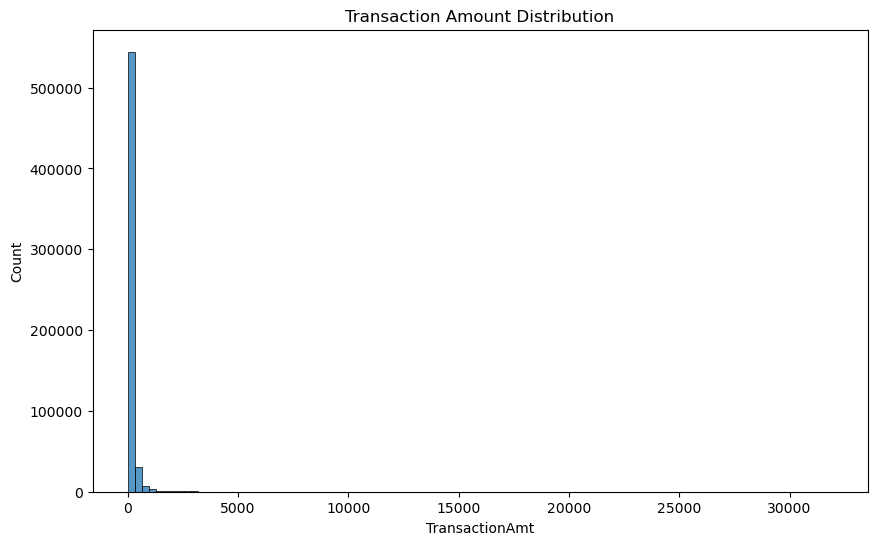

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(train['TransactionAmt'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

Right Skewed. Using log transformation.

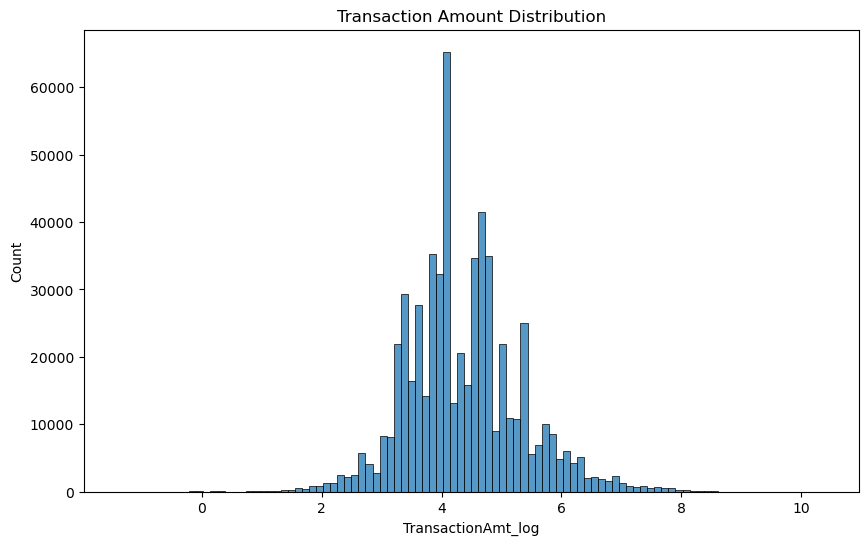

In [28]:
train['TransactionAmt_log']=np.log(train['TransactionAmt'])

plt.figure(figsize=(10,6))
sns.histplot(train['TransactionAmt_log'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

Transaction Amount is right skewed. Log transformation reduced skewness and help models like Logistic Regression.

In [29]:
train.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


## Analyzing isFraud 

For now not dropping as considering in fraud data misingness itself can carry information and need be random

In [30]:
median_non_fraud_amt=train[train['isFraud']==0]['TransactionAmt'].median()
print(f'Median Non-fraud amout is {median_non_fraud_amt}')
median_fraud_amt=train[train['isFraud']==1]['TransactionAmt'].median()
print(f'Median Fraud amout is {median_fraud_amt}')

Median Non-fraud amout is 68.5
Median Fraud amout is 75.0


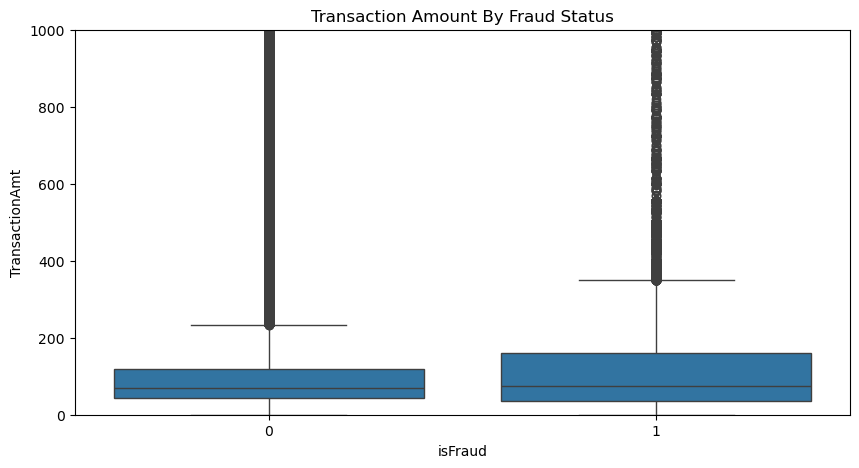

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train, x='isFraud', y='TransactionAmt')
plt.ylim(0,1000)
plt.title('Transaction Amount By Fraud Status')
plt.show()

## Analyzing TransactionDT

In [32]:
train['TransactionDT'].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

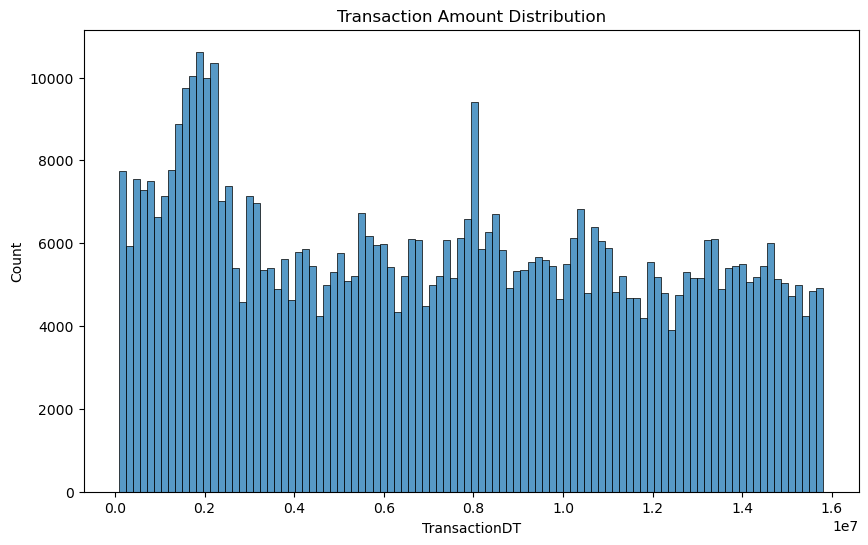

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(train['TransactionDT'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

## Analyzing Categorical Features

## ProductCD Analysis

`ProductCD` represents the product category associated with a transaction.

This feature was analyzed to determine:
- Which product categories are most common
- Whether fraud rates differ across product types

Key observations:
- Product W represents the majority of transactions.
- Product C showed the highest fraud rate among major categories.
- Fraud rates vary significantly across product groups.

This suggests that transaction product type may contain predictive information and should be retained for modeling.

In [34]:
train['ProductCD'].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

In [35]:
train['ProductCD'].value_counts(normalize=True)*100

ProductCD
W    74.452196
C    11.602770
R     6.383818
H     5.592170
S     1.969045
Name: proportion, dtype: float64

<Axes: xlabel='ProductCD', ylabel='count'>

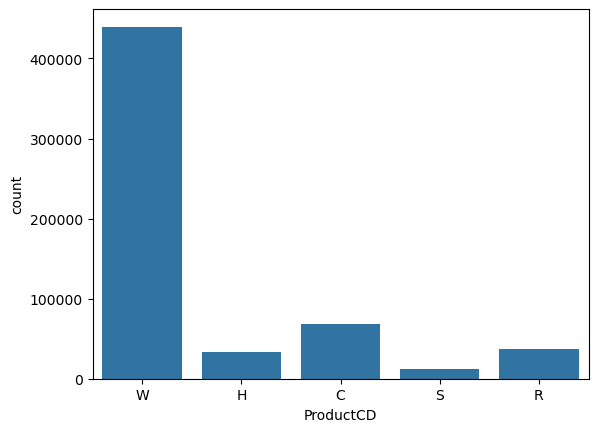

In [36]:
sns.countplot(data=train, x='ProductCD')

In [37]:
## Fraud By ProductCD
## Fraud Rate

ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64


<Axes: xlabel='ProductCD'>

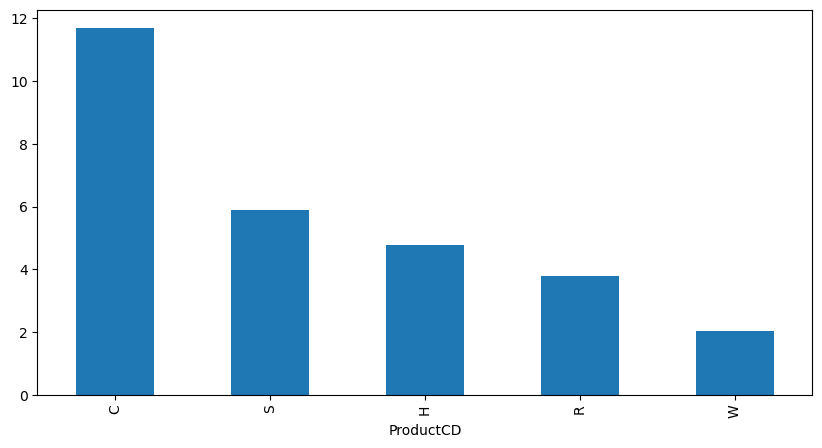

In [38]:
fraud_rate=train.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)*100
print(fraud_rate)
fraud_rate.plot(kind='bar', figsize=(10,5))

## Card Features Analysis

Card-related variables provide information about the payment method used during a transaction.

The following features were explored:

- card1
- card2
- card3
- card4
- card5
- card6

The analysis focused on:
- Missing value percentages
- Cardinality
- Distribution of card networks
- Fraud rates across card categories

In [39]:
card_features=['card1','card2','card3','card4','card5','card6']
train[card_features].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


In [40]:
train[card_features].isnull().mean()*100

card1    0.000000
card2    1.512683
card3    0.265012
card4    0.267044
card5    0.721204
card6    0.266028
dtype: float64

In [41]:
# cardinality

In [42]:
for col in card_features:
    print(col, train[col].nunique())

card1 13553
card2 500
card3 114
card4 4
card5 119
card6 4


### Card Network (card4)

`card4` represents the card network.

Examples:
- Visa
- Mastercard
- Discover
- American Express

Key observations:
- Visa dominates transaction volume.
- Discover showed the highest fraud rate among major card networks.
- Fraud behavior varies across card networks.

This indicates that card network information may be useful for fraud prediction.

In [43]:
train['card4'].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

<Axes: xlabel='card4', ylabel='count'>

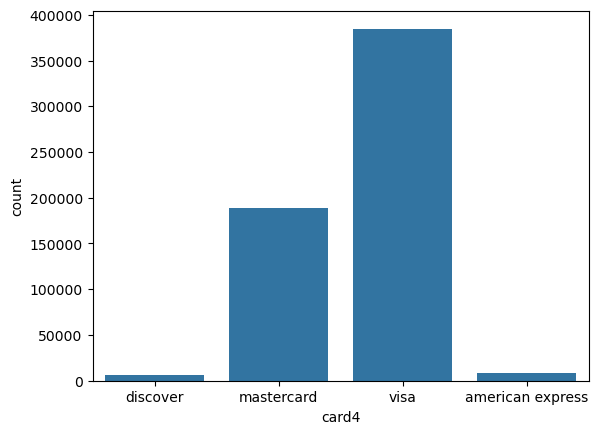

In [44]:
sns.countplot(data=train,x='card4')

In [45]:
card4_fraud=(train.groupby('card4')['isFraud'].mean()*100).sort_values(ascending=False)
card4_fraud

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

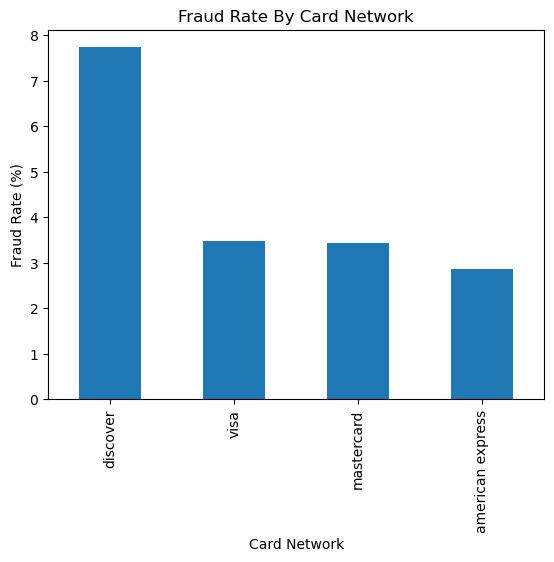

In [46]:
card4_fraud.plot(kind='bar')
plt.xlabel('Card Network')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate By Card Network')
plt.show()

### Card Type (card6)

`card6` represents the card type.

Examples:
- Debit
- Credit
- Charge Card

Key observations:
- Debit cards account for most transactions.
- Credit card transactions exhibit a higher fraud rate compared to debit cards.

This suggests that payment type contains meaningful fraud-related information.

In [47]:
train['card6'].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

<Axes: xlabel='card6', ylabel='count'>

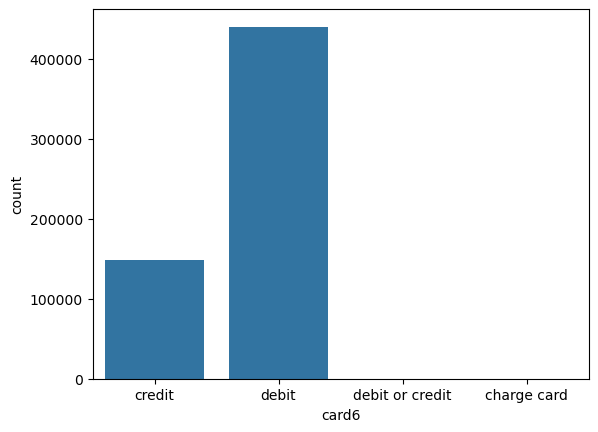

In [48]:
sns.countplot(data=train,x='card6')

In [49]:
card6_fraud=(train.groupby('card6')['isFraud'].mean()*100).sort_values(ascending=False)
card6_fraud

card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

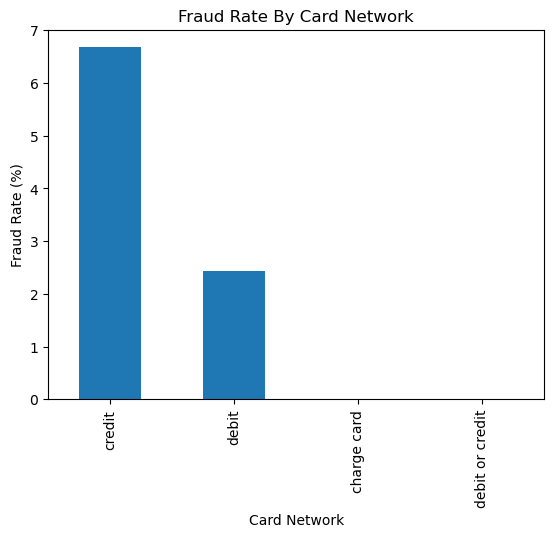

In [50]:
card6_fraud.plot(kind='bar')
plt.xlabel('Card Network')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate By Card Network')
plt.show()

## Address and Distance Features

Address-related features help identify geographic patterns in transactions.

Features analyzed:

- addr1
- addr2
- dist1
- dist2

The analysis focused on:
- Missing values
- Most common address groups
- Fraud rates by address
- Distance distributions

In [51]:
address_features=['addr1','addr2','dist1','dist2']
train[address_features].head(20)

,addr1,addr2,dist1,dist2
0,315.0,87.0,19.0,NaN
1,325.0,87.0,NaN,NaN
2,330.0,87.0,287.0,NaN
3,476.0,87.0,NaN,NaN
4,420.0,87.0,NaN,NaN
5,272.0,87.0,36.0,NaN
6,126.0,87.0,0.0,NaN
7,325.0,87.0,NaN,NaN
8,337.0,87.0,NaN,NaN
9,204.0,87.0,19.0,NaN


In [52]:
#Missing values
train[address_features].isnull().mean()*100

addr1    11.126427
addr2    11.126427
dist1    59.652352
dist2    93.628374
dtype: float64

In [53]:
for col in address_features:
    print(col, train[col].nunique())

addr1 332
addr2 74
dist1 2651
dist2 1751


### Address Region (addr1)

`addr1` contains location-related information.

Key observations:
- A small number of address groups account for a large portion of transactions.
- Fraud rates differ across address groups.
- Certain address grou|ps exhibit elevated fraud rates compared to others.

Address information may therefore provide useful geographic signals for fraud detection.

In [54]:
train['addr1'].value_counts().head(20)

addr1
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
315.0    23078
441.0    20827
272.0    20141
123.0    16105
126.0    15243
184.0    15160
337.0    15149
191.0    14979
181.0    13856
143.0     9806
476.0     9478
310.0     8486
472.0     8478
327.0     8425
512.0     8268
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 20 addr1 Value')

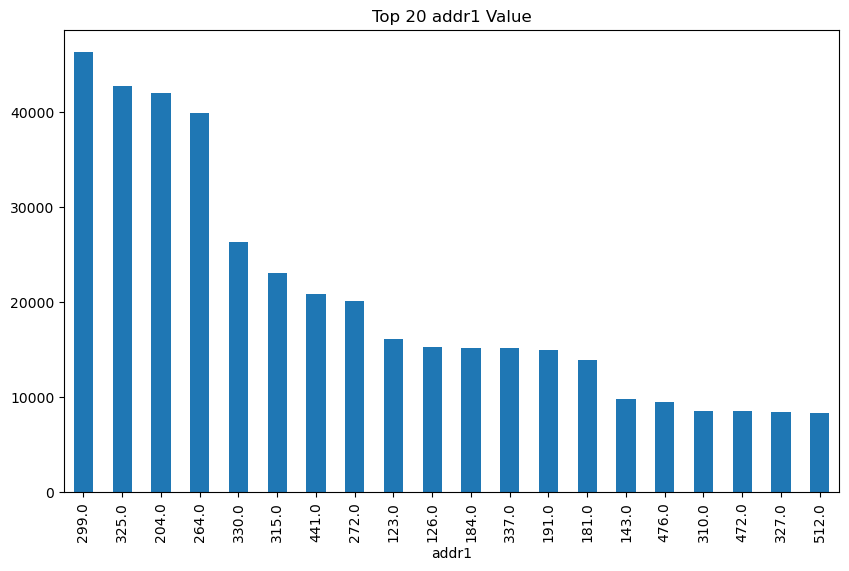

In [55]:
train['addr1'].value_counts().head(20).plot(kind='bar', figsize=(10,6))
plt.title('Top 20 addr1 Value')

In [56]:
addr1_fraud=(train.groupby('addr1')['isFraud'].mean()*100).sort_values(ascending=False).head(20)
addr1_fraud

addr1
305.0    66.666667
483.0    56.521739
501.0    50.000000
466.0    50.000000
471.0    50.000000
391.0    45.714286
431.0    34.210526
260.0    33.333333
432.0    28.947368
216.0    24.074074
479.0    23.076923
296.0    21.253406
399.0    20.000000
161.0    19.477435
239.0    19.354839
453.0    19.047619
171.0    16.666667
536.0    16.181230
426.0    15.625000
356.0    13.333333
Name: isFraud, dtype: float64

<Axes: xlabel='addr1'>

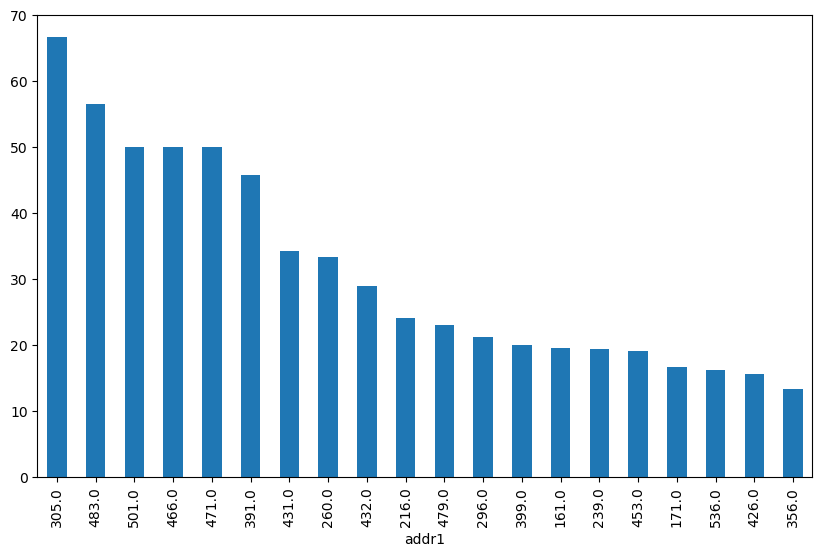

In [57]:
addr1_fraud.plot(kind='bar', figsize=(10,6))

In [58]:
top_addr1=train['addr1'].value_counts().head(20).index
top_addr1

Index([299.0, 325.0, 204.0, 264.0, 330.0, 315.0, 441.0, 272.0, 123.0, 126.0,
       184.0, 337.0, 191.0, 181.0, 143.0, 476.0, 310.0, 472.0, 327.0, 512.0],
      dtype='float64', name='addr1')

In [59]:
address1_fraud=(train[train["addr1"].isin(top_addr1)].groupby("addr1")["isFraud"].mean() *100).sort_values(ascending=False)
address1_fraud

addr1
512.0    3.434930
330.0    3.195496
476.0    3.165225
337.0    2.897881
272.0    2.859838
204.0    2.665397
441.0    2.559178
325.0    2.542631
126.0    2.532310
472.0    2.512385
123.0    2.471282
181.0    2.150693
299.0    2.125823
310.0    1.967947
327.0    1.946588
264.0    1.825934
315.0    1.780917
191.0    1.662327
184.0    1.358839
143.0    1.264532
Name: isFraud, dtype: float64

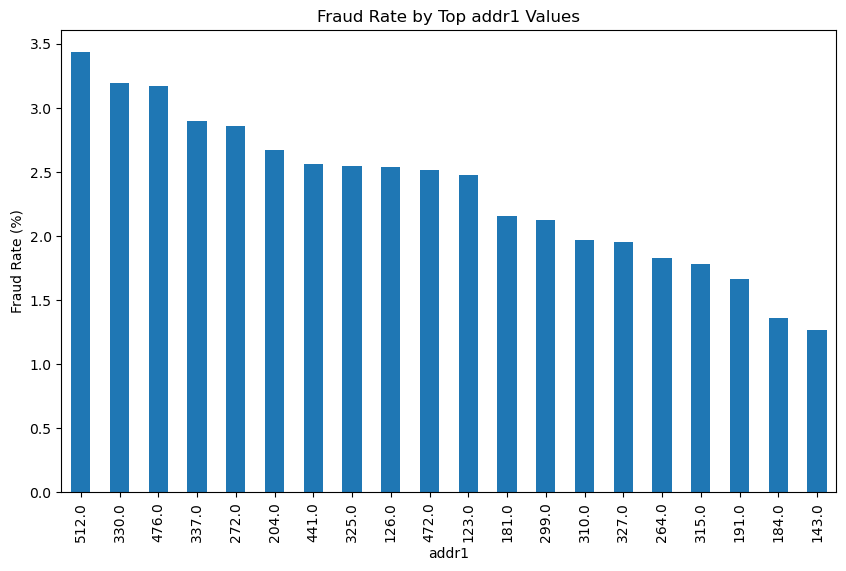

In [60]:
address1_fraud.plot(kind='bar',figsize=(10,6))
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Top addr1 Values")
plt.show()

### Distance Feature (dist1)

`dist1` represents a distance-related measure.

Key observations:
- The feature contains substantial missing values.
- Most observed values are concentrated near zero.
- Larger distance values occur less frequently.

Distance-related behavior may capture unusual transaction patterns and should be retained for further analysis.

In [61]:
train['dist1'].describe()

count    238269.000000
mean        118.502180
std         371.872026
min           0.000000
25%           3.000000
50%           8.000000
75%          24.000000
max       10286.000000
Name: dist1, dtype: float64

In [62]:
train['dist1'].value_counts().head(20)

dist1
0.0     19824
1.0     18330
2.0     17028
4.0     13067
3.0     12808
5.0     12004
6.0      9843
7.0      9340
8.0      7731
9.0      7728
10.0     6288
11.0     6047
12.0     5384
14.0     4603
13.0     4559
15.0     3451
16.0     3390
18.0     2818
17.0     2766
19.0     2429
Name: count, dtype: int64

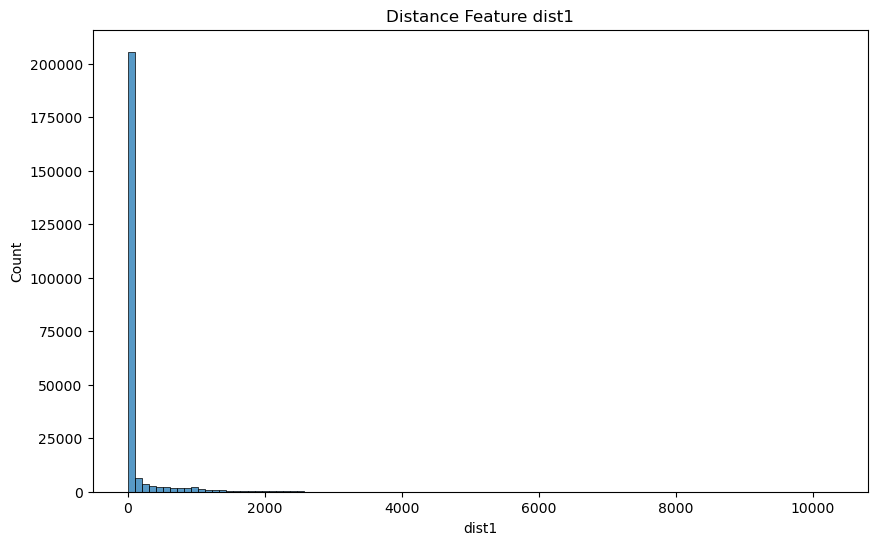

In [63]:
plt.figure(figsize=(10,6))
sns.histplot(train,x='dist1',bins=100)
plt.title("Distance Feature dist1")
plt.show()

In [64]:
dist1_fraud=(train.groupby('dist1')['isFraud'].mean() *100).head(20)
dist1_fraud

dist1
0.0     1.916868
1.0     2.793235
2.0     1.174536
3.0     1.171143
4.0     1.645366
5.0     2.224259
6.0     1.462969
7.0     1.466809
8.0     1.513388
9.0     1.889234
10.0    1.892494
11.0    1.786010
12.0    0.984398
13.0    1.316078
14.0    1.955247
15.0    1.680672
16.0    1.651917
17.0    1.373825
18.0    1.383960
19.0    2.140799
Name: isFraud, dtype: float64

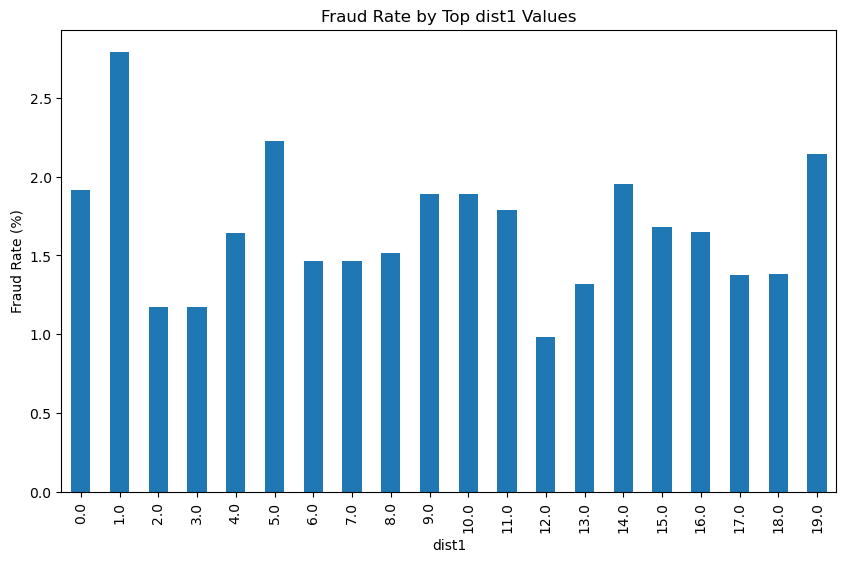

In [65]:
dist1_fraud.plot(kind='bar',figsize=(10,6))
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Top dist1 Values")
plt.show()

## Email Domain Analysis

Email domains can provide behavioral and provider-level information about users.

The following features were explored:

- P_emaildomain
- R_emaildomain

Where:
- P_emaildomain = purchaser email domain
- R_emaildomain = recipient email domain

In [66]:
email_features=['P_emaildomain', 'R_emaildomain']
train[email_features].head(10)

,P_emaildomain,R_emaildomain
0,NaN,NaN
1,gmail.com,NaN
2,outlook.com,NaN
3,yahoo.com,NaN
4,gmail.com,NaN
5,gmail.com,NaN
6,yahoo.com,NaN
7,mail.com,NaN
8,anonymous.com,NaN
9,yahoo.com,NaN


In [67]:
train[email_features].isnull().mean()*100

P_emaildomain    15.994852
R_emaildomain    76.751617
dtype: float64

### Purchaser Email Domain

The most common purchaser email domains include:

- gmail.com
- yahoo.com
- hotmail.com
- anonymous.com

Fraud rates vary across domains, suggesting that email providers may contain predictive information.

In [68]:
train['P_emaildomain'].value_counts().head(20)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
charter.net         816
Name: count, dtype: int64

<Axes: title={'center': 'Top 20  P_Email Domain'}, xlabel='P_emaildomain'>

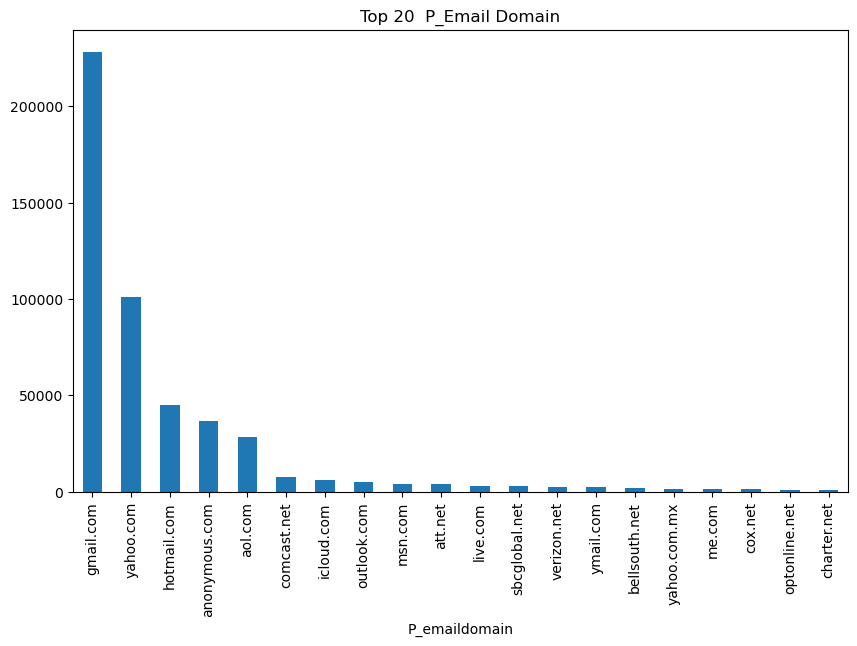

In [69]:
train['P_emaildomain'].value_counts().head(20).plot(kind='bar',figsize=(10,6), title='Top 20  P_Email Domain')

### Recipient Email Domain

The recipient email feature contains a large proportion of missing values.

Despite the missingness, several domains show distinct fraud patterns and may still contribute predictive value.

In [71]:
P_email_fraud=(train.groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False)*100).head(20)

<Axes: title={'center': 'Fraud Rate by Top P_emaildomain Values'}, xlabel='P_emaildomain', ylabel='Fraud Rate (%)'>

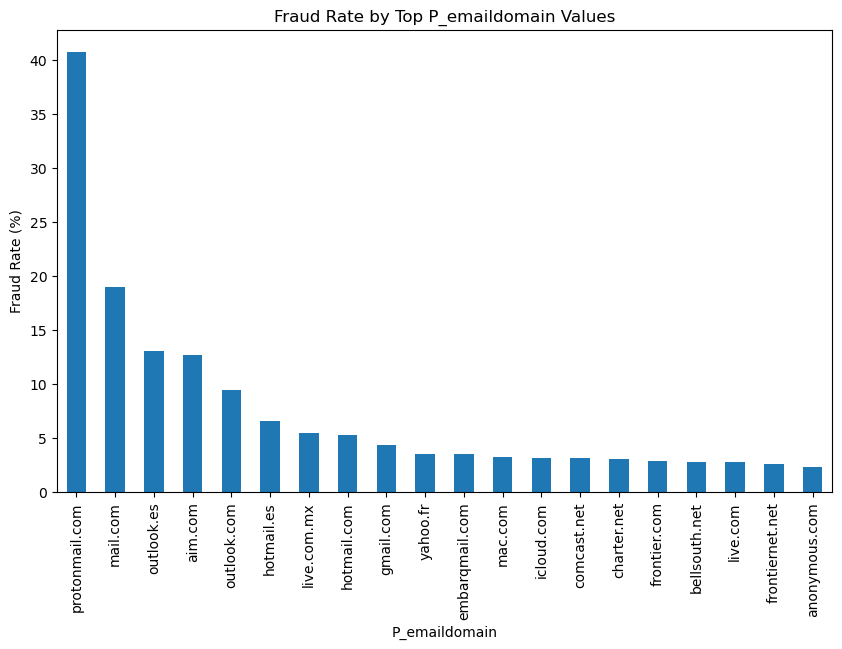

In [72]:
P_email_fraud.plot(kind='bar',figsize=(10,6), title="Fraud Rate by Top P_emaildomain Values",ylabel='Fraud Rate (%)')

In [73]:
## R_emaildomain

<Axes: title={'center': 'Top 20 R_Email Domain'}, xlabel='R_emaildomain'>

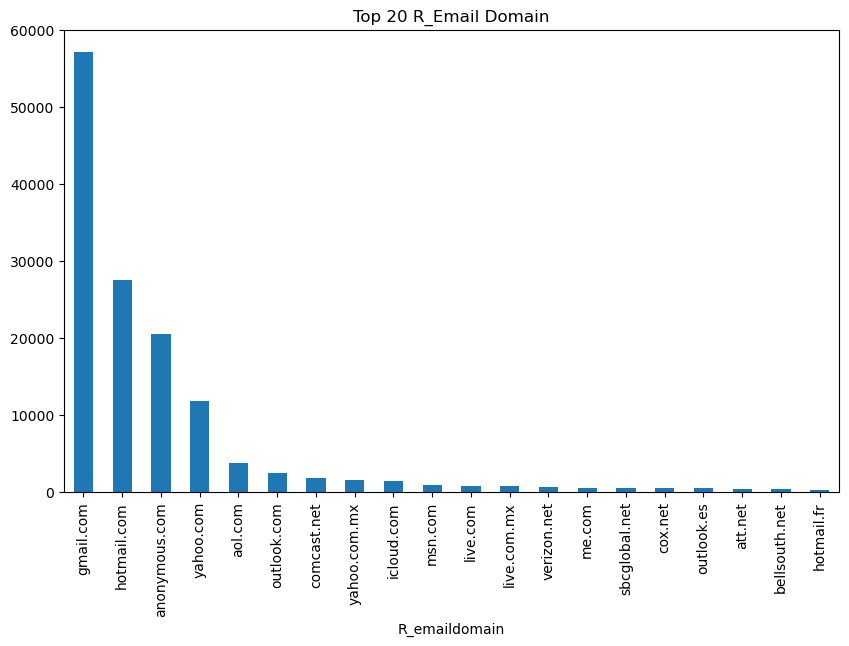

In [74]:
train['R_emaildomain'].value_counts().head(20).plot(kind='bar',figsize=(10,6), title='Top 20 R_Email Domain')

In [75]:
#Fraud Rate By R_Email Domain

In [76]:
R_email_fraud=(train.groupby('R_emaildomain')['isFraud'].mean().sort_values(ascending=False)*100).head(20)

<Axes: title={'center': 'Fraud Rate by Top R_emaildomain Values'}, xlabel='R_emaildomain', ylabel='Fraud Rate (%)'>

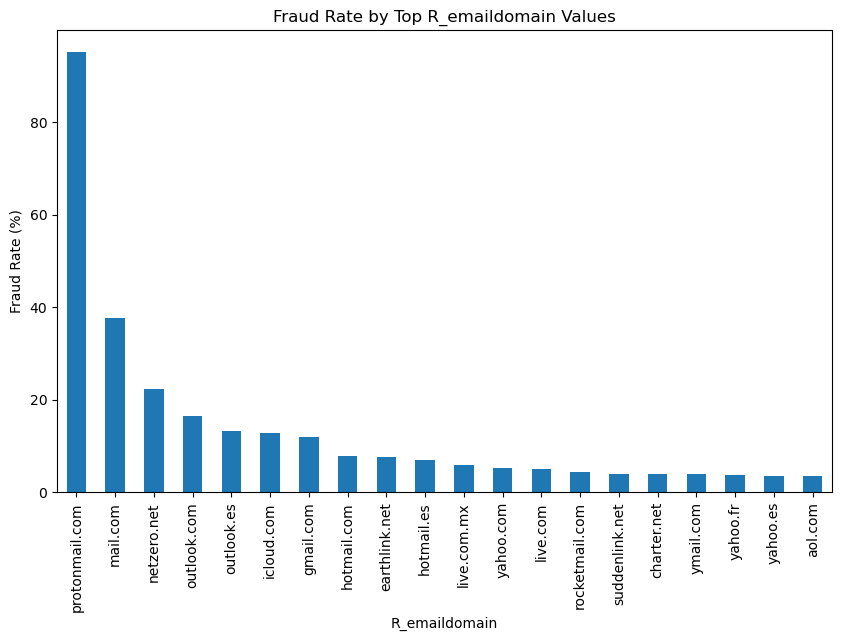

In [77]:
R_email_fraud.plot(kind='bar',figsize=(10,6), title="Fraud Rate by Top R_emaildomain Values",ylabel='Fraud Rate (%)')

In [78]:
train['match_email']=(train['P_emaildomain']==train['R_emaildomain']).astype(int)
train['match_email'].value_counts()

match_email
0    488036
1    102504
Name: count, dtype: int64

In [79]:
train.groupby('match_email')['isFraud'].mean()*100

match_email
0    2.207009
1    9.650355
Name: isFraud, dtype: float64

## Device Features Analysis

Device-related features provide information about the hardware, browser, and operating system used during a transaction.

These features may capture behavioral and technological differences between legitimate and fraudulent users.

The analysis focuses on:

- DeviceType
- DeviceInfo
- id_30 (Operating System)
- id_31 (Browser)

The goal is to identify device-level patterns that may contribute to fraud prediction.

In [80]:
device_features=['DeviceType','DeviceInfo','id_30','id_31']

In [81]:
train[device_features].isnull().mean()*100

DeviceType    76.155722
DeviceInfo    79.905510
id_30         86.865411
id_31         76.245132
dtype: float64

In [82]:
train[device_features].value_counts()

DeviceType  DeviceInfo            id_30          id_31                  
desktop     Windows               Windows 10     chrome 63.0                5822
            Trident/7.0           Windows 7      ie 11.0 for desktop        3668
            Windows               Windows 7      chrome 63.0                3579
                                  Windows 10     edge 16.0                  3559
mobile      iOS Device            iOS 11.1.2     mobile safari 11.0         3050
                                                                            ... 
            R1                    Android 6.0    chrome 63.0 for android       1
                                                 chrome 62.0 for android       1
            QTASUN1 Build/NRD90M  Android 7.0    chrome 66.0 for android       1
                                                 chrome 62.0 for android       1
            rv:60.0               Android 8.0.0  firefox                       1
Name: count, Length: 2068, dtype: in

In [83]:
train[device_features].nunique()

DeviceType       2
DeviceInfo    1786
id_30           75
id_31          130
dtype: int64

### Operating System Analysis (id_30)

The original `id_30` feature contains operating system names and version numbers.

Examples include:

- Windows 10
- Android 7.0
- iOS 11
- Mac OS X

To reduce cardinality and improve interpretability, operating systems are grouped into broader categories:

- Windows
- Android
- iOS
- Mac
- Missing

This transformation helps identify platform-level fraud patterns while reducing feature sparsity.

In [85]:
train['id_30'].nunique()

75

In [86]:
train['id_30'].unique()

array([nan, 'Android 7.0', 'iOS 11.1.2', 'Mac OS X 10_11_6', 'Windows 10',
       'Android', 'Linux', 'iOS 11.0.3', 'Mac OS X 10_7_5',
       'Mac OS X 10_12_6', 'Mac OS X 10_13_1', 'iOS 11.1.0',
       'Mac OS X 10_9_5', 'Windows 7', 'Windows 8.1', 'Mac', 'iOS 10.3.3',
       'Mac OS X 10.12', 'Mac OS X 10_10_5', 'Mac OS X 10_11_5',
       'iOS 9.3.5', 'Android 5.1.1', 'Android 7.1.1', 'Android 6.0',
       'iOS 10.3.1', 'Mac OS X 10.9', 'iOS 11.1.1', 'Windows Vista',
       'iOS 10.3.2', 'iOS 11.0.2', 'Mac OS X 10.11', 'Android 8.0.0',
       'iOS 10.2.0', 'iOS 10.2.1', 'iOS 11.0.0', 'Mac OS X 10.10',
       'Mac OS X 10_12_3', 'Mac OS X 10_12', 'Android 6.0.1', 'iOS',
       'Mac OS X 10.13', 'Mac OS X 10_12_5', 'Mac OS X 10_8_5',
       'iOS 11.0.1', 'iOS 10.0.2', 'Android 5.0.2', 'Windows XP',
       'iOS 11.2.0', 'Mac OS X 10.6', 'Windows 8', 'Mac OS X 10_6_8',
       'Mac OS X 10_11_4', 'Mac OS X 10_12_1', 'iOS 10.1.1',
       'Mac OS X 10_11_3', 'Mac OS X 10_12_4', 'Mac OS X 10

In [87]:
train.loc[train['id_30'].str.contains('Windows',na=False),'id_30']='Windows'
train.loc[train['id_30'].str.contains('iOS',na=False),'id_30']='iOS'
train.loc[train['id_30'].str.contains('Android',na=False),'id_30']='Android'
train.loc[train['id_30'].str.contains('Mac OS',na=False),'id_30']='Mac'

train['id_30'].fillna("Missing",inplace=True)

In [88]:
train['id_30'].nunique()

8

In [89]:
train['id_30'].value_counts().head(20)

id_30
Missing    512975
Windows     36739
iOS         19782
Mac         13580
Android      6303
Linux        1136
other          15
func           10
Name: count, dtype: int64

### Browser Analysis (id_31)

The original browser feature contains detailed browser names and version numbers.

Examples include:

- Chrome 62
- Mobile Safari 11
- Firefox 57
- Edge 15

To simplify analysis, browsers were grouped into broader categories:

- Chrome
- Safari
- Firefox
- Edge
- Samsung Browser
- Opera
- Other

Grouping reduces cardinality and improves model interpretability.

In [90]:
train['id_31'].unique()

array([nan, 'samsung browser 6.2', 'mobile safari 11.0', 'chrome 62.0',
       'chrome 62.0 for android', 'edge 15.0', 'mobile safari generic',
       'chrome 49.0', 'chrome 61.0', 'edge 16.0', 'safari generic',
       'edge 14.0', 'chrome 56.0 for android', 'firefox 57.0',
       'chrome 54.0 for android', 'mobile safari uiwebview', 'chrome',
       'chrome 62.0 for ios', 'firefox', 'chrome 60.0 for android',
       'mobile safari 10.0', 'chrome 61.0 for android',
       'ie 11.0 for desktop', 'ie 11.0 for tablet', 'mobile safari 9.0',
       'chrome generic', 'other', 'chrome 59.0 for android',
       'firefox 56.0', 'android webview 4.0', 'chrome 55.0', 'opera 49.0',
       'ie', 'chrome 55.0 for android', 'firefox 52.0',
       'chrome 57.0 for android', 'chrome 56.0',
       'chrome 46.0 for android', 'chrome 58.0', 'firefox 48.0',
       'chrome 59.0', 'samsung browser 4.0', 'edge 13.0',
       'chrome 53.0 for android', 'chrome 58.0 for android',
       'chrome 60.0', 'mobile sa

In [91]:
train.loc[train['id_31'].str.contains('chrome',case=False,na=False),'id_31']='Chrome'
train.loc[train['id_31'].str.contains('firefox',case=False,na=False),'id_31']='FireFox'
train.loc[train['id_31'].str.contains('safari',case=False,na=False),'id_31']='Safari'
train.loc[train['id_31'].str.contains('edge',case=False,na=False),'id_31']='Edge'
train.loc[train['id_31'].str.contains('opera',case=False,na=False),'id_31']='Opera'
train.loc[train['id_31'].str.contains('samsung',case=False,na=False),'id_31']='Samsung'
train.loc[train['id_31'].str.contains('google',case=False,na=False),'id_31']='Google'
train.loc[train['id_31'].str.contains('ie',case=False,na=False),'id_31']='ie'
train.loc[train['id_31'].str.contains('android',case=False,na=False),'id_31']='Android'
train.loc[train['id_31'].str.contains('windows',case=False,na=False),'id_31']='Windows'

train['id_31'].fillna('Missing',inplace=True)

In [92]:
train['id_31'].nunique()

35

In [93]:
train['id_31'].value_counts().head(20)

id_31
Missing      450258
Chrome        76059
Safari        37281
ie            10018
FireFox        7017
Edge           6401
Samsung        2247
Opera           449
other           312
Android         239
Google          146
Windows          25
silk             19
mobile           11
ZTE/Blade         9
line              6
comodo            6
maxthon           6
icedragon         5
aol               5
Name: count, dtype: int64

### Device Type Analysis

`DeviceType` identifies whether a transaction originated from a desktop or mobile device.

This analysis evaluates:

- Transaction volume by device category
- Fraud rate by device category

Understanding device usage patterns can help identify whether certain device categories are associated with elevated fraud risk.

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64


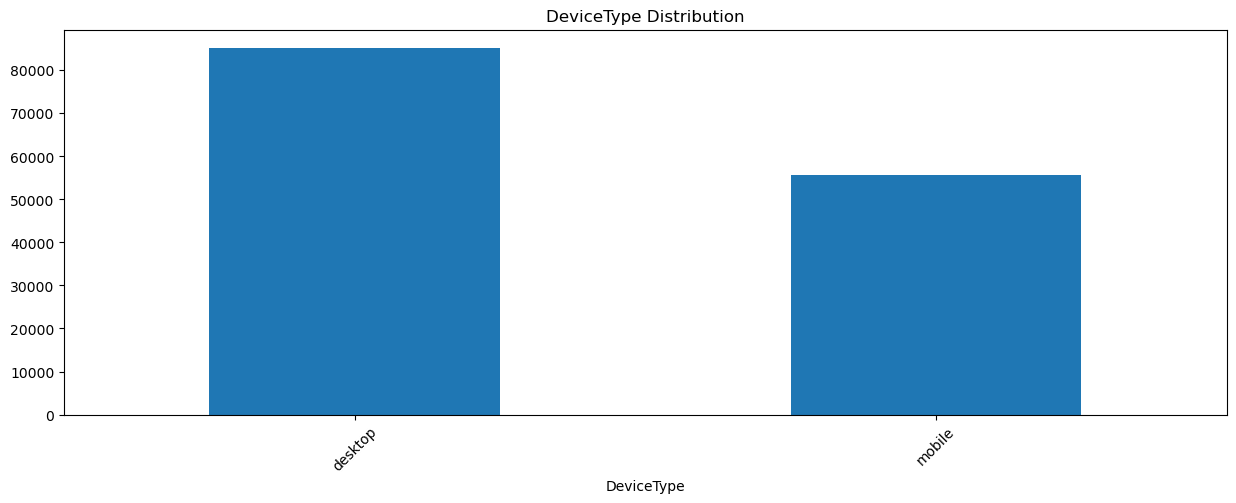

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64


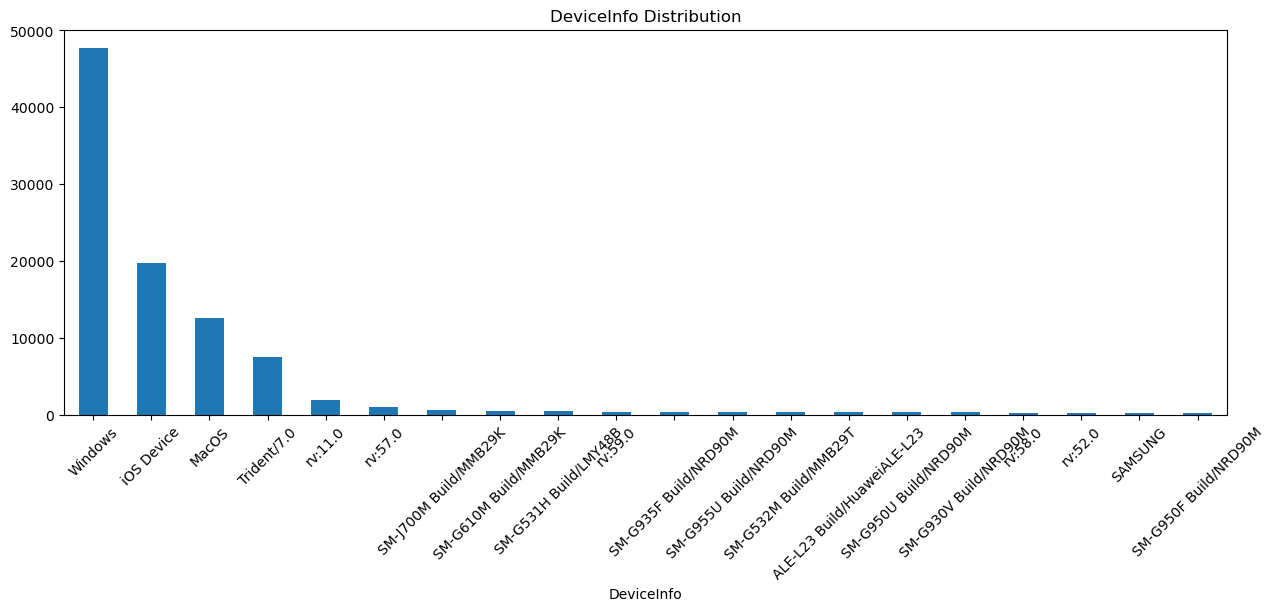

id_30
Missing    512975
Windows     36739
iOS         19782
Mac         13580
Android      6303
Linux        1136
other          15
func           10
Name: count, dtype: int64


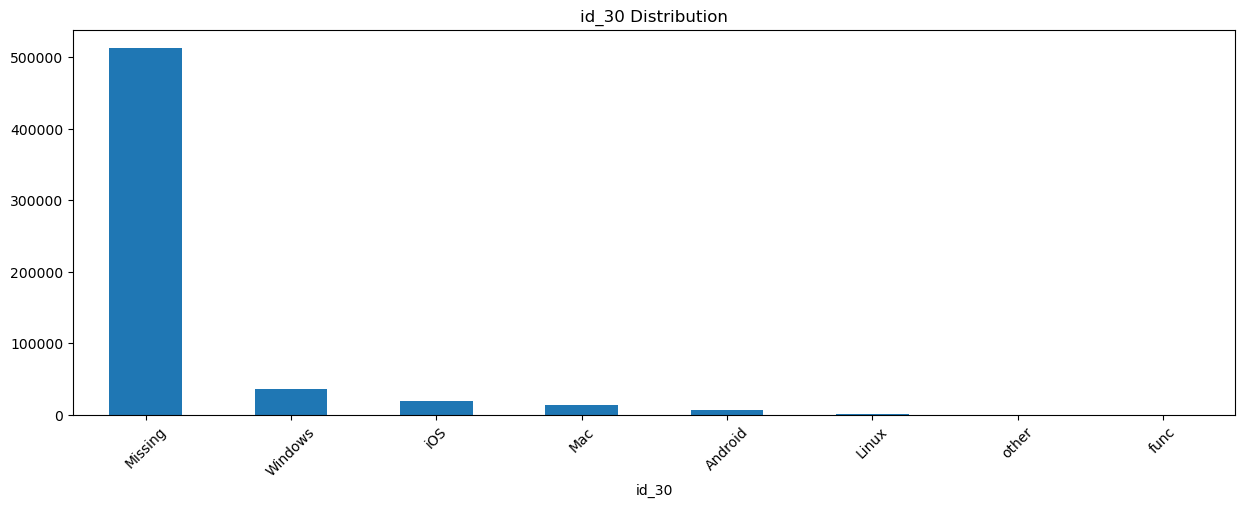

id_31
Missing      450258
Chrome        76059
Safari        37281
ie            10018
FireFox        7017
Edge           6401
Samsung        2247
Opera           449
other           312
Android         239
Google          146
Windows          25
silk             19
mobile           11
ZTE/Blade         9
line              6
comodo            6
maxthon           6
icedragon         5
aol               5
Name: count, dtype: int64


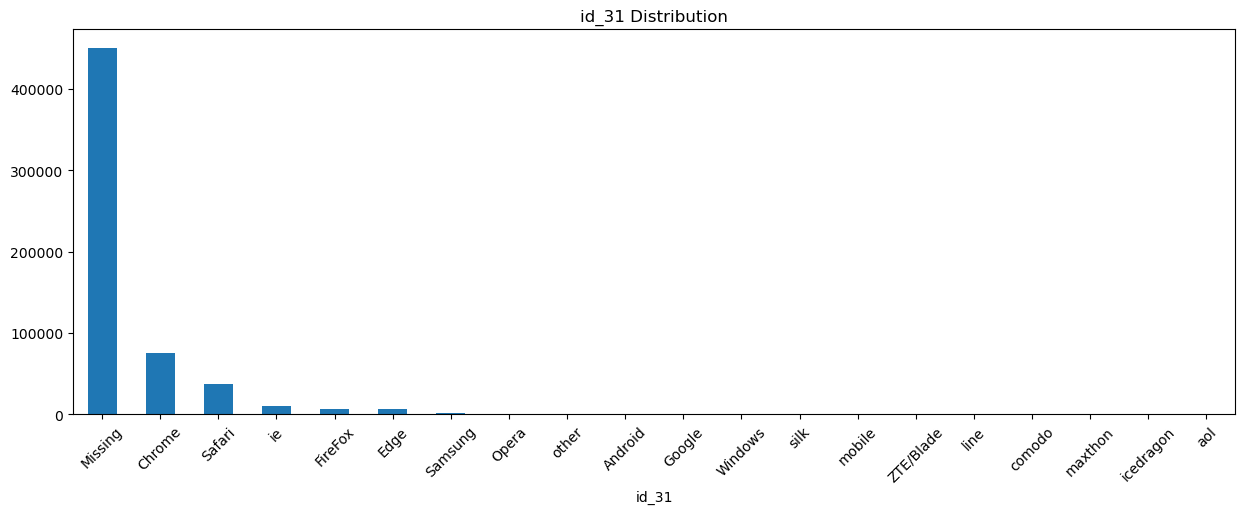

In [94]:
for col in device_features:
    top_20=train[col].value_counts().head(20)
    # print(f'{col} values:')
    print(top_20)
    plt.figure(figsize=(15,5))
    top_20.plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

DeviceType
mobile     10.166232
desktop     6.521458
Name: isFraud, dtype: float64


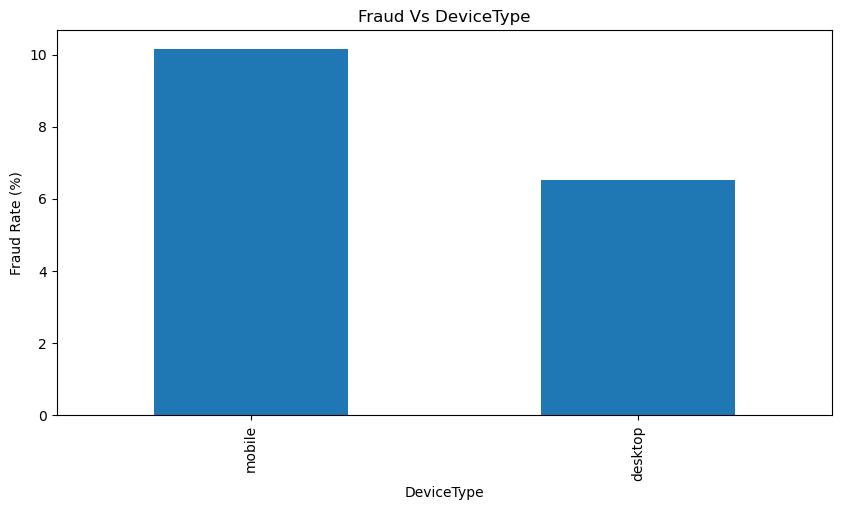

DeviceInfo
ZTE-Z835                       100.0
Dream                          100.0
SM-T285M                       100.0
A5002                          100.0
A466BG                         100.0
SM-T530                        100.0
Blade L3 Build/KOT49H          100.0
RNE-L23 Build/HUAWEIRNE-L23    100.0
SAMSUNG-SM-N900A               100.0
MotoG3-TE Build/MPD24.65-33    100.0
N9560 Build/NMF26F             100.0
NOKIA                          100.0
NX785QC8G                      100.0
Nexus 6 Build/MOB30M           100.0
XT1033                         100.0
G3123 Build/40.0.A.6.175       100.0
ZTE-Z956                       100.0
TAB7                           100.0
rv:14.0                        100.0
rv:29.0                        100.0
Name: isFraud, dtype: float64


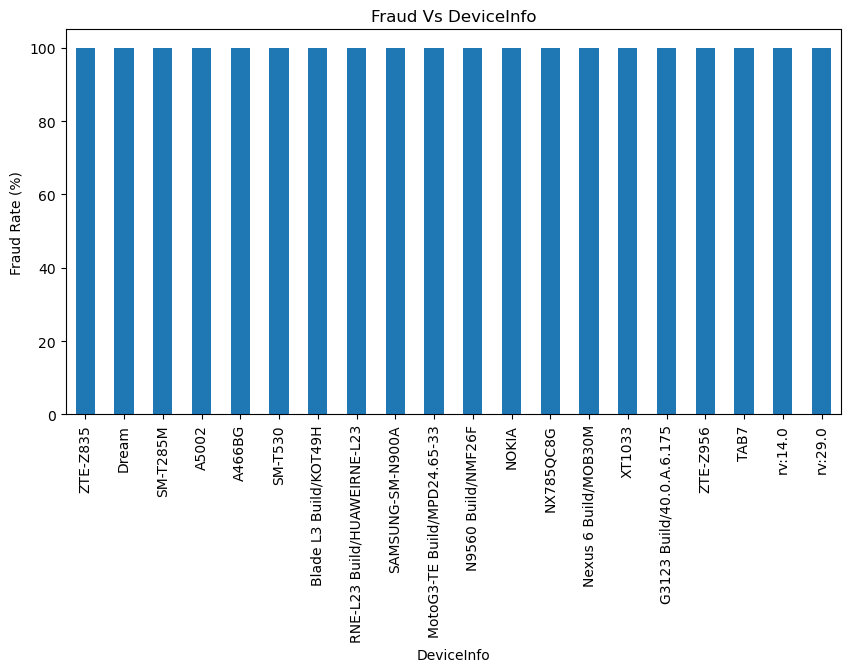

id_30
other      60.000000
Android     8.599080
Linux       7.482394
iOS         6.268325
Windows     3.451373
Missing     3.357084
Mac         2.194404
func        0.000000
Name: isFraud, dtype: float64


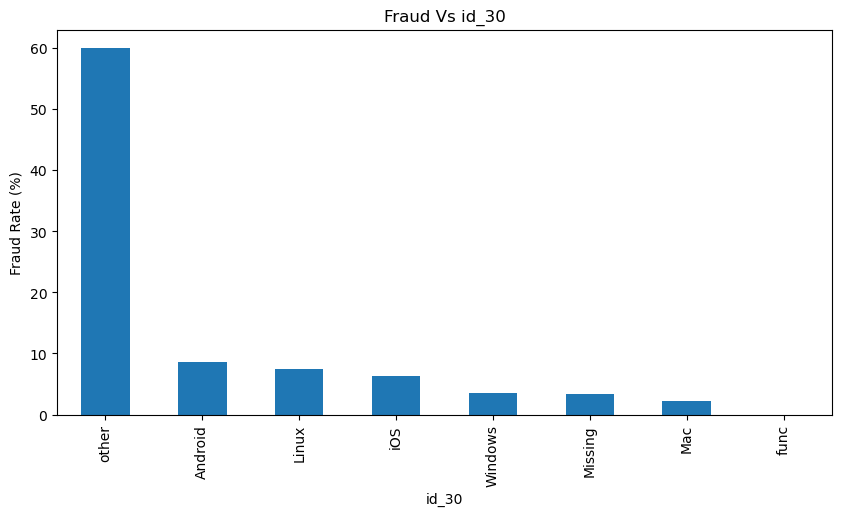

id_31
icedragon      100.000000
Lanix/Ilium     66.666667
comodo          66.666667
Opera           31.625835
mobile          27.272727
ZTE/Blade       22.222222
other           19.551282
Android         15.899582
Chrome           9.595183
Samsung          8.722741
FireFox          7.880861
Safari           6.394678
Edge             3.515076
ie               2.545418
Missing          2.108125
Google           2.054795
line             0.000000
maxthon          0.000000
LG/K-200         0.000000
Cherry           0.000000
Name: isFraud, dtype: float64


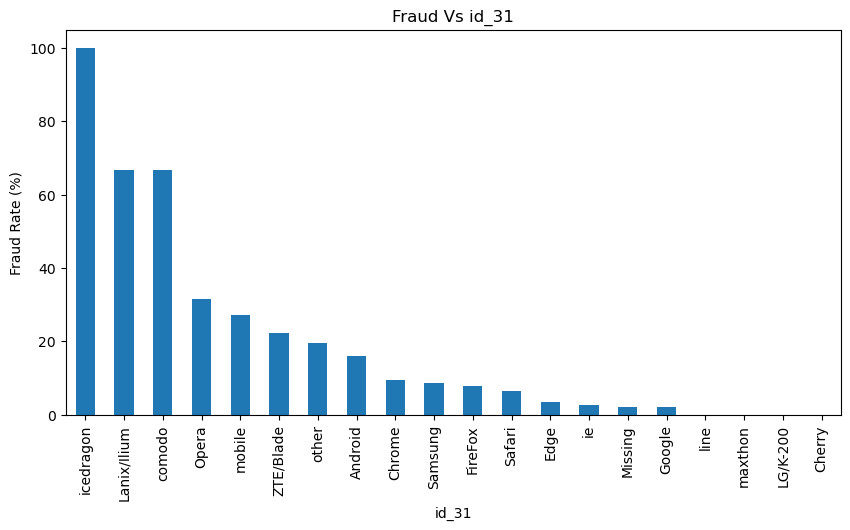

In [95]:
for col in device_features:
    device_fraud=(train.groupby(col)['isFraud'].mean()*100).sort_values(ascending=False).head(20)
    print(device_fraud)
    device_fraud.plot(kind='bar', figsize=(10,5), ylabel='Fraud Rate (%)')
    plt.title(f'Fraud Vs {col}')
    plt.show()

### Device Information Analysis

`DeviceInfo` contains detailed hardware and device identifiers.

Examples include:

- Windows
- iOS Device
- MacOS
- Samsung Mobile Devices
- Huawei Devices

Unlike DeviceType, this feature contains highly granular device-level information and exhibits extremely high cardinality.

In [96]:
device_summary=train.groupby('DeviceInfo')['isFraud'].agg({'count','sum','mean'})\
    .rename(columns={'count':'total_transactions','sum':'fraud_transactions','mean':'fraud_rate'}).reset_index()\
    .sort_values('fraud_transactions', ascending=False)

device_summary['fraud_rate']=device_summary['fraud_rate']*100

device_summary.head(20)

,DeviceInfo,total_transactions,fraud_transactions,fraud_rate
1598,Windows,47722,3121,6.539961
1727,iOS Device,19782,1240,6.268325
723,MacOS,12573,278,2.211087
1725,hi6210sft Build/MRA58K,190,180,94.736842
1125,SM-A300H Build/LRX22G,203,169,83.251232
1769,rv:57.0,962,103,10.706861
1552,Trident/7.0,7440,96,1.290323
1743,rv:11.0,1901,76,3.997896
490,LG-D320 Build/KOT49I.V10a,71,61,85.915493
1360,SM-J700M Build/MMB29K,549,60,10.928962


### Device Information Insights

Key observations:

- DeviceInfo contains thousands of unique values.
- A small number of device types account for most transactions.
- Some device categories exhibit elevated fraud rates.

However, high fraud rates should always be interpreted alongside transaction volume because rare device categories may produce unstable fraud estimates.

Due to the high cardinality of this feature, grouping and feature engineering may be more effective than using raw values directly.

since we see some devices have 100% fraud in them checking for the count of the transaction from device to determine if these devices are used specifically for fraud transations

## M Features Analysis

The M features (M1-M9) are anonymized binary matching indicators provided in the IEEE-CIS dataset.

Although the exact meaning of these variables is not publicly disclosed, they are believed to represent consistency or matching relationships between transaction attributes.

The objective of this analysis is to:

- Understand the distribution of M features
- Evaluate missing value patterns
- Compare fraud rates across different M feature values
- Identify whether matching behavior differs between fraudulent and non-fraudulent transactions

Since fraudsters often exhibit behavioral inconsistencies, these matching indicators may provide useful predictive signals for fraud detection.

In [97]:
m_features=["M1","M2","M3","M4","M5","M6","M7","M8","M9"]

In [98]:
train[m_features].isnull().mean()*100

M1    45.907136
M2    45.907136
M3    45.907136
M4    47.658753
M5    59.349409
M6    28.678836
M7    58.635317
M8    58.633115
M9    58.633115
dtype: float64

In [99]:
for col in m_features:
    print(train[col].value_counts())

M1
T    319415
F        25
Name: count, dtype: int64
M2
T    285468
F     33972
Name: count, dtype: int64
M3
T    251731
F     67709
Name: count, dtype: int64
M4
M0    196405
M2     59865
M1     52826
Name: count, dtype: int64
M5
F    132491
T    107567
Name: count, dtype: int64
M6
F    227856
T    193324
Name: count, dtype: int64
M7
F    211374
T     32901
Name: count, dtype: int64
M8
F    155251
T     89037
Name: count, dtype: int64
M9
T    205656
F     38632
Name: count, dtype: int64


M1
F    0.000000
T    1.985505
Name: isFraud, dtype: float64


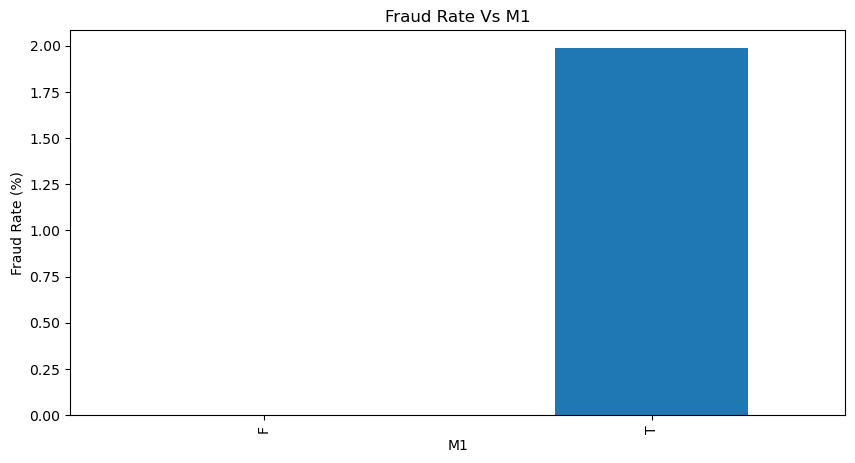

M2
F    3.485223
T    1.806858
Name: isFraud, dtype: float64


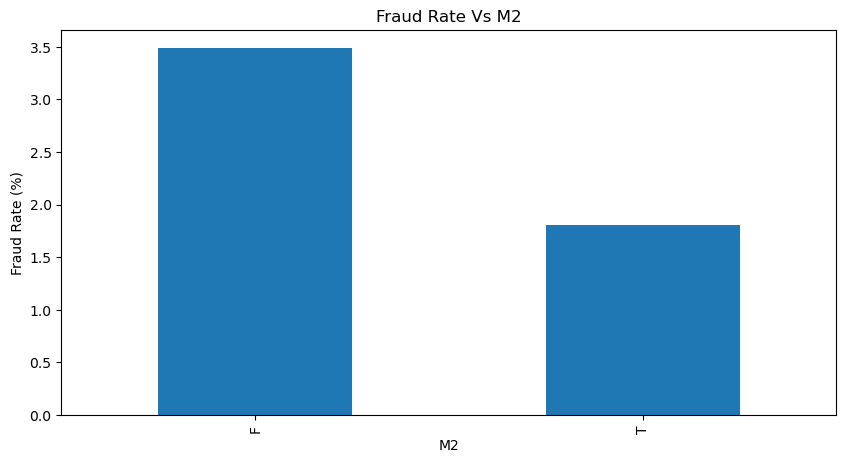

M3
F    3.026186
T    1.705392
Name: isFraud, dtype: float64


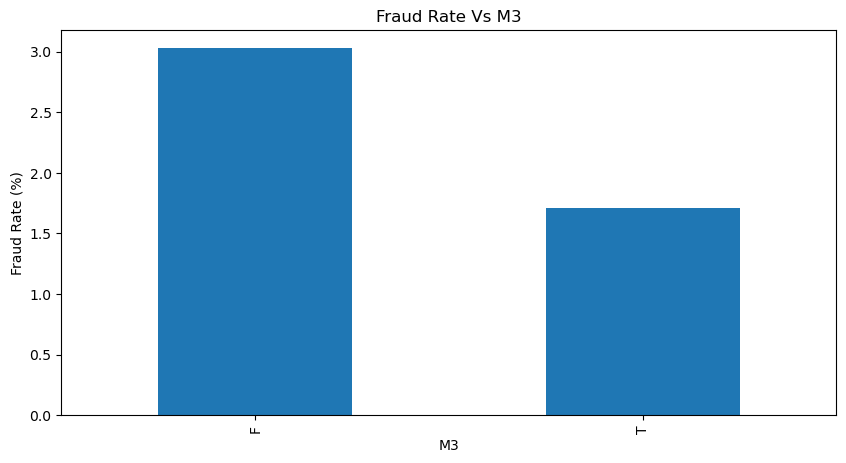

M4
M0     3.664876
M1     2.705107
M2    11.373925
Name: isFraud, dtype: float64


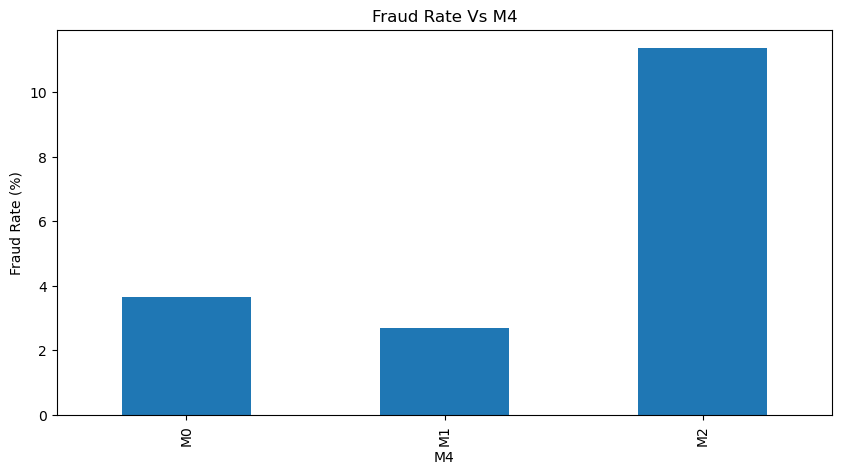

M5
F    2.652256
T    3.769744
Name: isFraud, dtype: float64


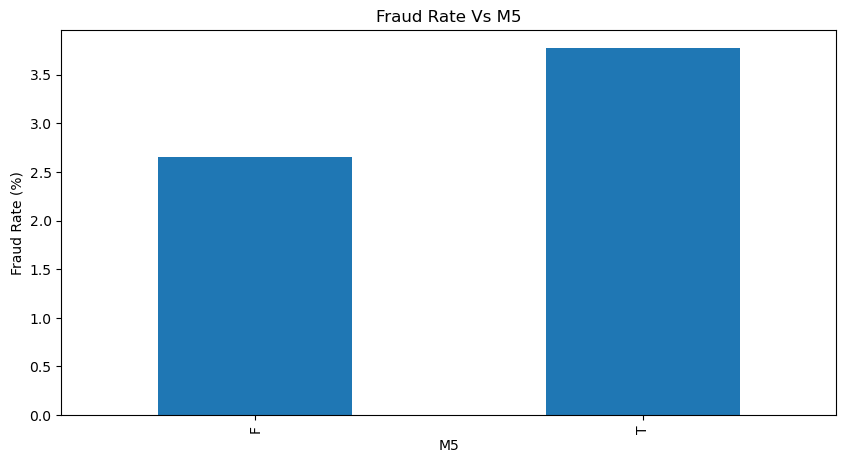

M6
F    2.368601
T    1.704393
Name: isFraud, dtype: float64


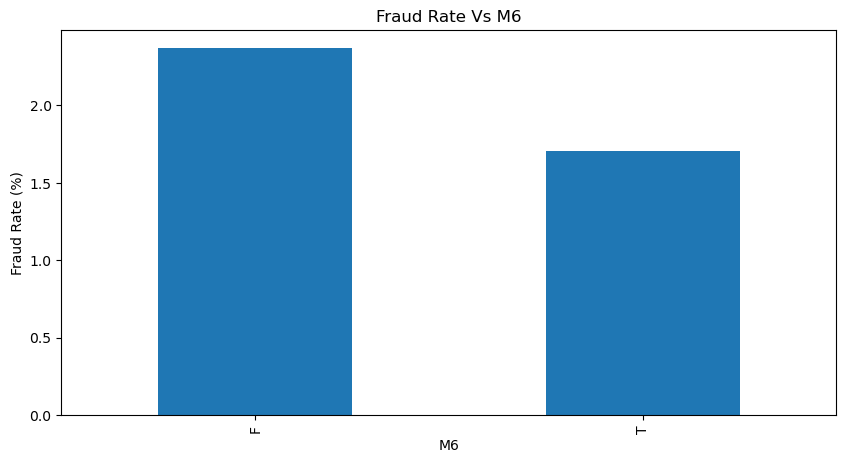

M7
F    1.934486
T    2.212699
Name: isFraud, dtype: float64


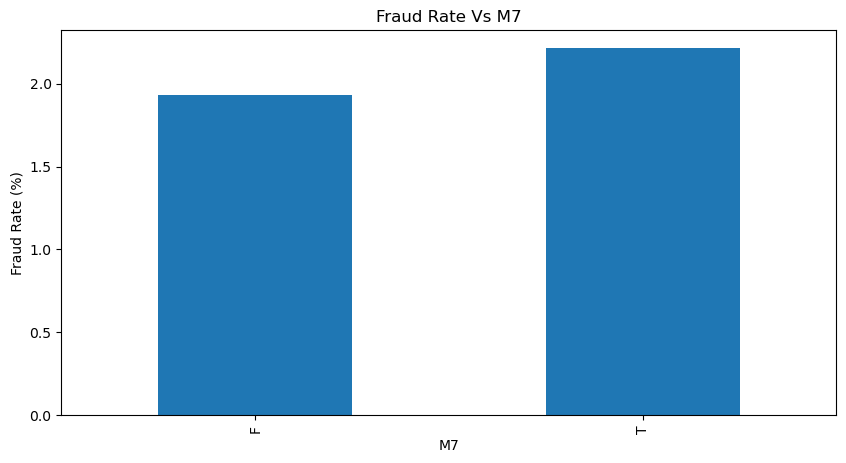

M8
F    2.172611
T    1.621798
Name: isFraud, dtype: float64


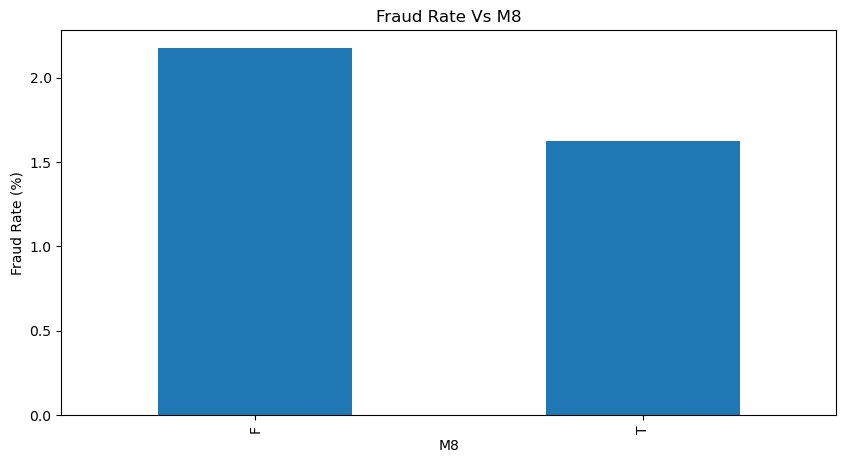

M9
F    3.000104
T    1.778698
Name: isFraud, dtype: float64


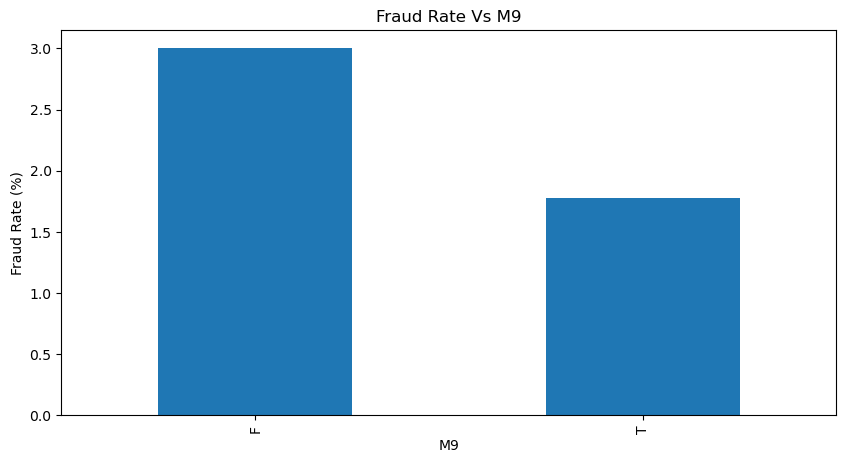

In [100]:
for col in m_features:
    fraud_rate=train.groupby(col)['isFraud'].mean()*100
    fraud_rate.plot(kind='bar',figsize=(10,5),ylabel='Fraud Rate (%)', title=f'Fraud Rate Vs {col}')
    print(fraud_rate)
    plt.show()

### M Feature Insights

Key observations:

- Several M features exhibit different distributions between fraud and non-fraud transactions.
- Missing values are common in some M features and may themselves contain information.
- Transactions with certain matching patterns appear to have higher fraud rates.
- The M feature family captures behavioral consistency signals that may not be reflected in traditional transaction variables.

Overall, the M features appear to provide useful behavioral information and should be retained for modeling.

## C Features Analysis

The C feature family contains anonymized count-based variables. Although the exact business meaning of each C feature is not publicly available, these variables may capture transaction frequency, grouping behavior, or repeated activity patterns.

The analysis focuses on:

- Number of C features
- Missing value percentage
- Summary statistics
- Correlation with the fraud target

Since fraud behavior may involve repeated attempts, unusual transaction counts, or abnormal activity patterns, C features may provide useful predictive signal.

In [101]:
c_features=[col for col in train.columns if col.startswith('C')]
print(f'Number of C-features is {len(c_features)}')
print(f'The C features are {c_features}')

Number of C-features is 14
The C features are ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [102]:
train[c_features].isnull().mean()*100

C1     0.0
C2     0.0
C3     0.0
C4     0.0
C5     0.0
C6     0.0
C7     0.0
C8     0.0
C9     0.0
C10    0.0
C11    0.0
C12    0.0
C13    0.0
C14    0.0
dtype: float64

In [103]:
train[c_features].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


## Determine relationship of C features and isFraud

In [104]:
c_features_isfraud=pd.concat([train[c_features],train['isFraud']],axis=1)
c_features_isfraud

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,isFraud
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0
3,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,0
590536,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0
590537,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0
590538,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,1.0,1.0,5.0,1.0,0


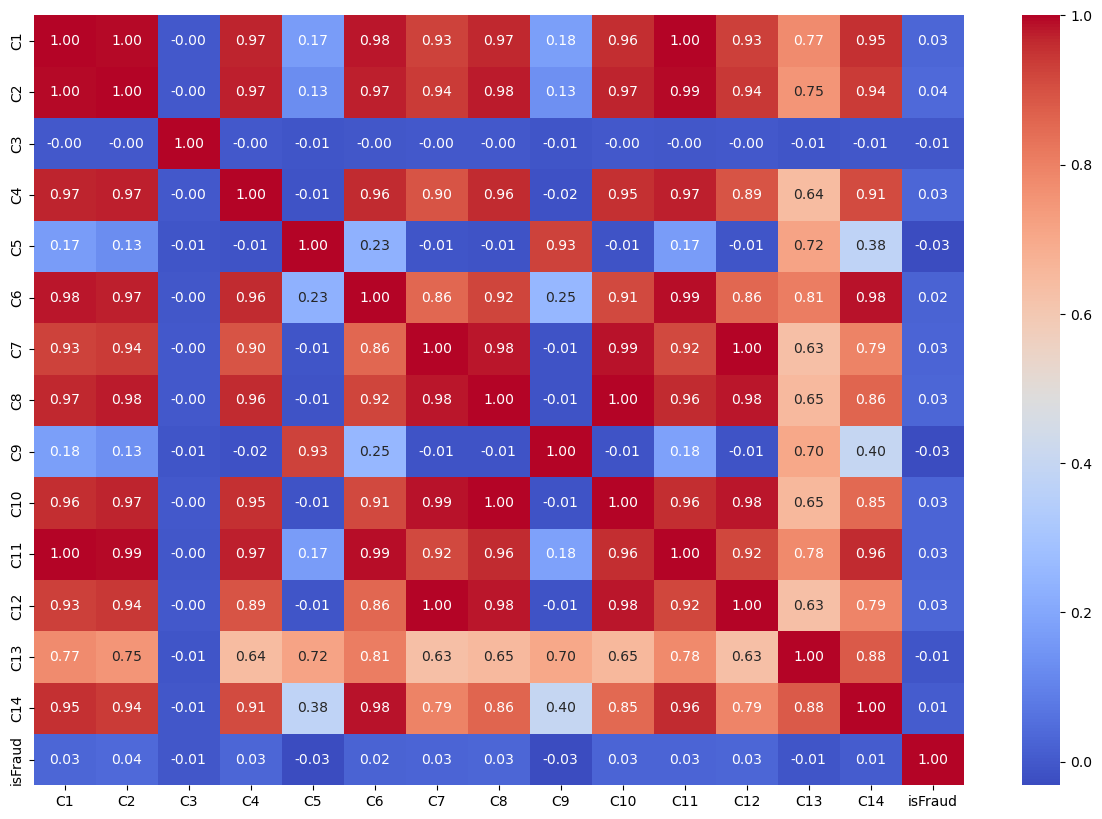

In [105]:
plt.figure(figsize=(15,10))
sns.heatmap(c_features_isfraud.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

In [106]:
c_fraud_corr=c_features_isfraud.corr()['isFraud'].sort_values(ascending=False).drop('isFraud')
c_fraud_corr

C2     0.037229
C8     0.032139
C12    0.031905
C1     0.030570
C4     0.030382
C10    0.028396
C7     0.028160
C11    0.027484
C6     0.020909
C14    0.007921
C3    -0.006833
C13   -0.011146
C5    -0.030754
C9    -0.031703
Name: isFraud, dtype: float64

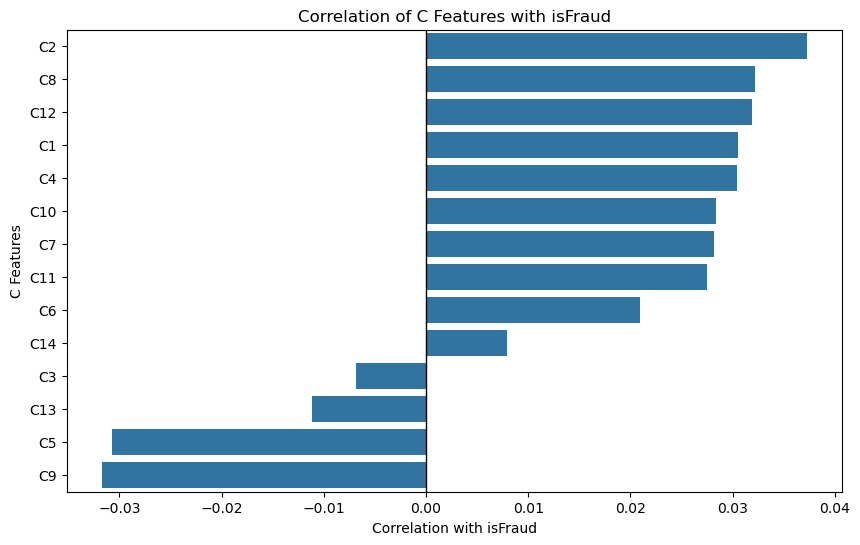

In [107]:
plt.figure(figsize=(10,6))
sns.barplot(x=c_fraud_corr.values, y=c_fraud_corr.index)
plt.axvline(0, color='black', linewidth=1)
plt.title("Correlation of C Features with isFraud")
plt.xlabel("Correlation with isFraud")
plt.ylabel("C Features")
plt.show()

### C Feature Insights

Key observations:

- C features do not have missing values, which makes them reliable inputs for modeling.
- Most C features have weak individual correlation with fraud.
- C2, C8, C12, C1, and C4 show the strongest positive correlations with fraud among the C feature family.
- C5 and C9 show negative correlation with fraud.

Although the individual correlations are small, these features may still be useful when combined with other transaction, card, device, and behavioral features in machine learning models.

## D Features Analysis

The D feature family contains anonymized time-distance or time-delta related variables.

The exact meaning of individual D features is not publicly disclosed, but these variables are commonly treated as time-related behavioral features in the IEEE-CIS fraud dataset.

The analysis focuses on:

- Number of D features
- Missing value patterns
- Correlation with fraud

Since fraud behavior may differ based on transaction timing, recency, or time gaps between activities, D features may provide useful information for fraud detection.

In [108]:
d_features=[col for col in train.columns if col.startswith('D')]
print(f'Number of D-features is {len(d_features)}')
print(f'The D-features are {d_features}')

Number of D-features is 17
The D-features are ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'DeviceType', 'DeviceInfo']


In [109]:
d_features.remove('DeviceType')
d_features.remove('DeviceInfo')

In [110]:
print(f'Number of D-features is {len(d_features)}')
print(f'The D-features are {d_features}')

Number of D-features is 15
The D-features are ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']


In [111]:
train[d_features].isnull().mean()*100

D1      0.214888
D2     47.549192
D3     44.514851
D4     28.604667
D5     52.467403
D6     87.606767
D7     93.409930
D8     87.312290
D9     87.312290
D10    12.873302
D11    47.293494
D12    89.041047
D13    89.509263
D14    89.469469
D15    15.090087
dtype: float64

### D Feature Missing Value Insights

Key observations:

- D features have mixed missingness.
- Some features such as D1, D10, and D15 are relatively complete.
- Other features such as D6, D7, D8, D9, D12, D13, and D14 have very high missing values.

Because missingness can itself be meaningful in fraud detection, high-missing D features are not automatically removed during EDA. Instead, missing value handling is deferred to the feature engineering and modeling stage.

## Determine relationship of D features and isFraud



In [112]:
d_features_isfraud=pd.concat([train[d_features],train['isFraud']],axis=1)

d_features_isfraud

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,isFraud
0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,0
1,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0
2,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,0
3,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,0
590536,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0
590537,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0
590538,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,0


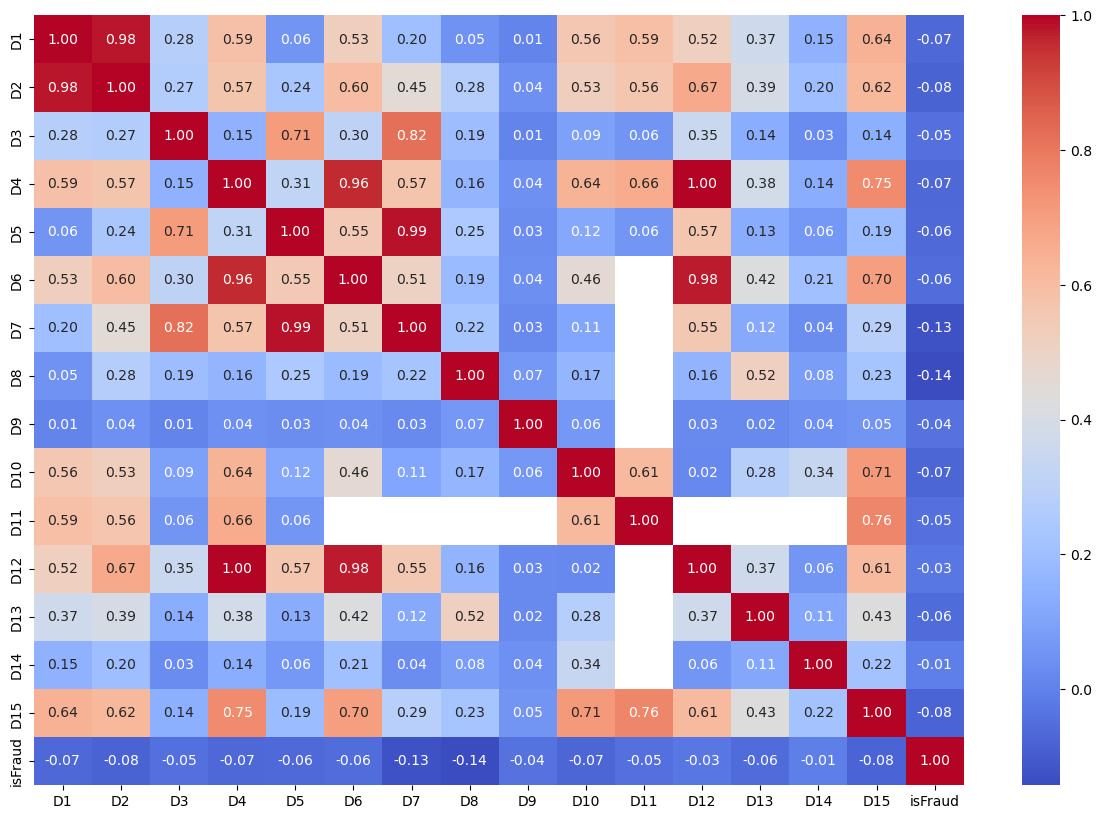

In [113]:
plt.figure(figsize=(15,10))

sns.heatmap(d_features_isfraud.corr(),annot=True,fmt='.2f',cmap='coolwarm')

plt.show()

In [114]:
d_fraud_corr=d_features_isfraud.corr()['isFraud'].sort_values(ascending=False).drop('isFraud')

d_fraud_corr

D14   -0.008663
D12   -0.028864
D9    -0.044253
D11   -0.045094
D3    -0.046271
D6    -0.057236
D13   -0.059430
D5    -0.064638
D1    -0.067193
D4    -0.067216
D10   -0.072002
D15   -0.077519
D2    -0.083583
D7    -0.127199
D8    -0.142636
Name: isFraud, dtype: float64

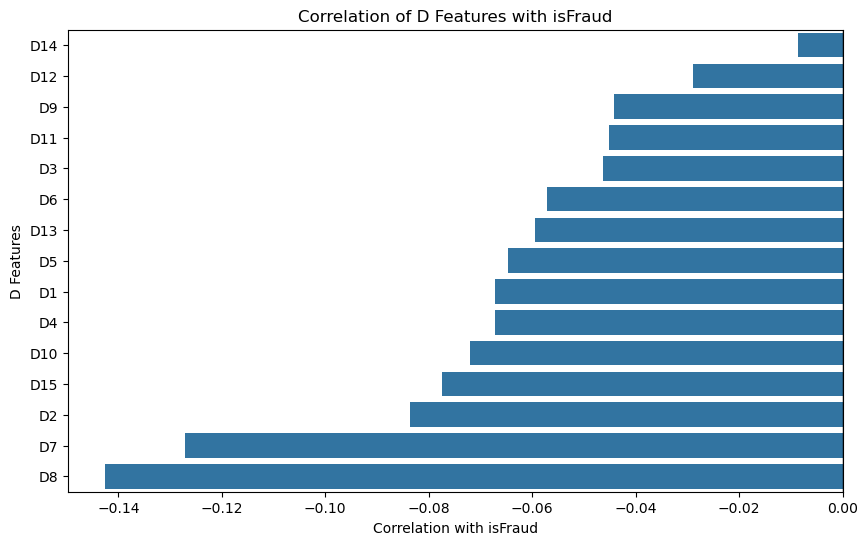

In [115]:
plt.figure(figsize=(10,6))

sns.barplot(x=d_fraud_corr.values, y=d_fraud_corr.index)

plt.axvline(0, color='black', linewidth=1)

plt.title("Correlation of D Features with isFraud")

plt.xlabel("Correlation with isFraud")

plt.ylabel("D Features")

plt.show()

### D Feature Insights

Key observations:

- Several D features show negative correlation with fraud.
- D2, D15, D10, D4, and D1 show stronger relationships with fraud compared with other D features.
- The correlations are still relatively weak individually, but this is common in fraud datasets.

D features may capture time-related behavioral differences and should be retained for modeling, especially features with lower missingness and stronger relationship with fraud.

## V Features Analysis

The V feature family contains a large number of anonymized engineered variables.

The exact meaning of individual V features is not publicly available. However, these variables are known to capture complex transaction relationships and are widely used in IEEE-CIS fraud detection modeling.

Because there are many V features, the analysis focuses on:

- Number of V features
- Missing value distribution
- Correlation with fraud
- Top V features by relationship with the target

In [116]:
v_features=[col for col in train.columns if col.startswith('V')]
print(f'Number of V-features is {len(v_features)}')

Number of V-features is 339


In [117]:
train[v_features].isnull().mean()*100

V1      47.293494
V2      47.293494
V3      47.293494
V4      47.293494
V5      47.293494
          ...    
V335    86.054967
V336    86.054967
V337    86.054967
V338    86.054967
V339    86.054967
Length: 339, dtype: float64

## Determine relationship of V features and isFraud

In [118]:
v_features_isfraud=pd.concat([train[v_features],train['isFraud']],axis=1)
v_features_isfraud.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,...,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,isFraud
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [119]:
v_fraud_corr=v_features_isfraud.corr()['isFraud'].abs().sort_values(ascending=False).drop('isFraud').head(20)

v_fraud_corr

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

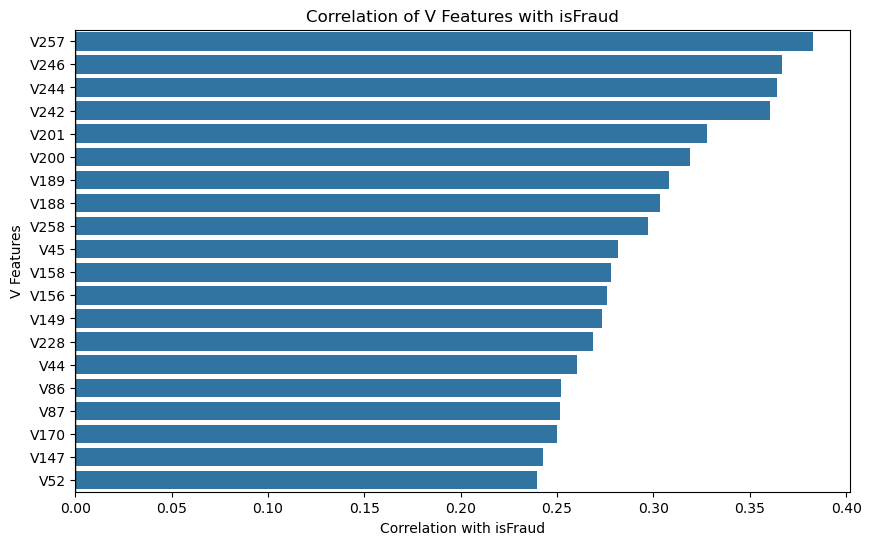

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(x=v_fraud_corr.values, y=v_fraud_corr.index)

plt.axvline(0, color='black', linewidth=1)

plt.title("Correlation of V Features with isFraud")

plt.xlabel("Correlation with isFraud")

plt.ylabel("V Features")

plt.show()



### V Feature Insights

Key observations:

- Several V features exhibit positive correlation with fraud transactions.
- Most correlations are relatively weak individually, which is common in fraud detection datasets.
- Even low individual correlations may become highly predictive when combined with other transaction, device, and behavioral features.
- The V feature family appears to capture complex transaction patterns that are difficult to interpret directly but may provide substantial predictive value for machine learning models.

Given the large number of V features and their potential importance, they should be considered for feature selection and model development.

## Mutual Information Ranking

Mutual Information (MI) was used to evaluate the relationship between selected features and the target variable (`isFraud`).

Unlike correlation, Mutual Information can capture:

* Linear relationships
* Non-linear relationships
* Complex dependencies

Higher MI scores indicate that a feature contains more information about the target variable.

The analysis was performed on representative transaction, card, address, distance, C-feature, and D-feature variables. Missing values were imputed using the median before calculating Mutual Information scores.


In [121]:
# selecting candidate features for mutual information analysis 

In [152]:
candidate_features = [
    #Transaction information
    "TransactionAmt",
    #card information
    "card1",
    "card2",
    "card3",
    "card5",
    #addess information
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    #c-feature
    "C1",
    "C2",
    "C13",
    #d-feature
    "D1",
    "D10",
    "D15"
]

In [153]:
#creating a copy of the dataset to retain original dataset
#.copy() - creates a new dataset and not impact the original dataset

In [154]:
mi_data=train[candidate_features +['isFraud']].copy()

In [155]:
for col in candidate_features:
    mi_data[col]=mi_data[col].fillna(mi_data[col].median())

In [156]:
X = mi_data[candidate_features]
y = mi_data['isFraud']
mi_scores=mutual_info_classif(X,y,random_state=42)

In [157]:
print(mi_scores)

[0.02810121 0.02811969 0.02006847 0.09793554 0.05023193 0.01402424
 0.16421017 0.00718369 0.04557773 0.00786562 0.00849118 0.0080489
 0.00551712 0.00571538 0.0064725 ]


In [158]:
mi_df=pd.DataFrame({'Feature':candidate_features,'MI Score':mi_scores})
mi_df

,Feature,MI Score
0,TransactionAmt,0.028101
1,card1,0.028120
2,card2,0.020068
3,card3,0.097936
4,card5,0.050232
5,addr1,0.014024
6,addr2,0.164210
7,dist1,0.007184
8,dist2,0.045578
9,C1,0.007866


In [159]:
mi_df=mi_df.sort_values(by='MI Score',ascending=False)
mi_df

,Feature,MI Score
6,addr2,0.164210
3,card3,0.097936
4,card5,0.050232
8,dist2,0.045578
1,card1,0.028120
0,TransactionAmt,0.028101
2,card2,0.020068
5,addr1,0.014024
10,C2,0.008491
11,C13,0.008049


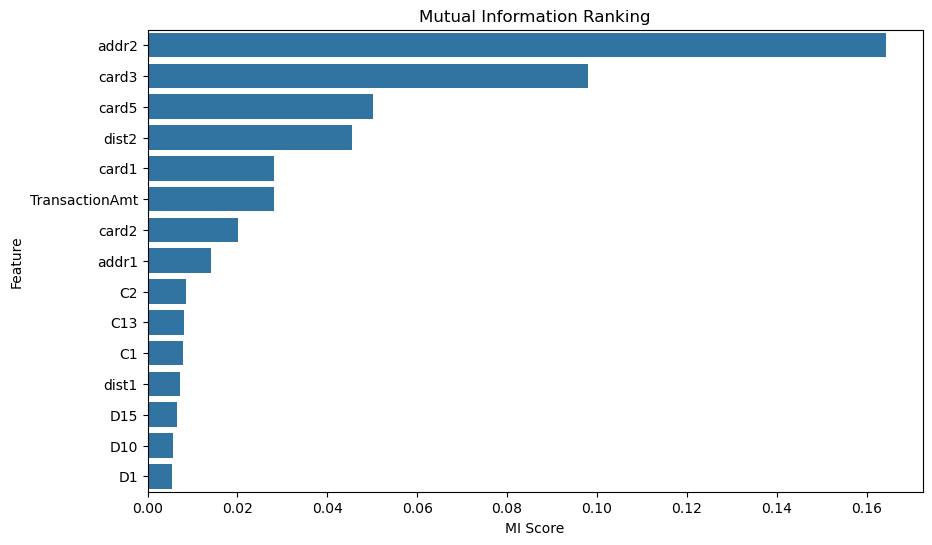

In [160]:

plt.figure(figsize=(10,6))
sns.barplot(data=mi_df,x='MI Score',y='Feature')
plt.title('Mutual Information Ranking')
plt.show()

### Mutual Information Insights

Among the selected features, `addr2`, `card3`, `card5`, `dist2`, `card1`, and `TransactionAmt` showed the strongest relationships with fraud.

Key observations:

* `addr2` exhibited the highest Mutual Information score, suggesting strong predictive potential.
* Card-related variables (`card1`, `card3`, and `card5`) contained meaningful fraud-related information.
* Transaction amount remained an important predictive feature.
* Distance-related features contributed additional signal despite containing missing values.
* C and D feature families showed relatively lower individual MI scores within the selected subset.

Mutual Information should be interpreted alongside exploratory analysis, statistical testing, feature engineering, and model-based feature importance because predictive value can also depend on feature interactions.


## Hypothesis Testing

Statistical hypothesis testing was performed to validate whether patterns observed during exploratory data analysis were statistically significant.

The following tests were used:

### Chi-Square Test

Used for categorical variables to determine whether fraud occurrence is associated with a specific category.

Features tested:

* ProductCD
* card4
* card6
* DeviceType

### Welch's T-Test

Used to compare the average transaction amount between fraud and non-fraud transactions.

Welch's T-Test was selected because it does not assume equal variance between groups.

### Mann-Whitney U Test

Used as a non-parametric alternative to the T-Test.

This test is particularly useful when data is skewed or does not follow a normal distribution.


## Chi-Square test: 
To determine isFraud is associated with another categorical feature

In [183]:
def chi_square_test(df, feature, target="isFraud"):
    contigency_table=pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contigency_table)

    print(f'Feature: {feature}')
    print(f'Chi-sqaure statistics {chi2:4f}')
    print(f'P-value {p_value:.6f}')
    print(f'Degrees of Freedom: {dof}')

    if p_value<0.05:
        print('Reject H0')
        print(f'{feature} is statistically associated with fraud')
    else:
        print('Not enough evidence to Reject H0')
        print(f'{feature} is not have statistical significant assosciation with fraud')

In [184]:
chi_square_test(train, "ProductCD")

Feature: ProductCD
Chi-sqaure statistics 16742.171529
P-value 0.000000
Degrees of Freedom: 4
Reject H0
ProductCD is statistically associated with fraud


In [185]:
chi_square_test(train, "card4")

Feature: card4
Chi-sqaure statistics 364.874139
P-value 0.000000
Degrees of Freedom: 3
Reject H0
card4 is statistically associated with fraud


In [186]:
chi_square_test(train, "card6")

Feature: card6
Chi-sqaure statistics 5957.032292
P-value 0.000000
Degrees of Freedom: 3
Reject H0
card6 is statistically associated with fraud


In [187]:
chi_square_test(train, "DeviceType")

Feature: DeviceType
Chi-sqaure statistics 609.623764
P-value 0.000000
Degrees of Freedom: 1
Reject H0
DeviceType is statistically associated with fraud


# Welch's t-test
### t-test to determine if isfraud is associated with numerical feature 


In [190]:
#Create fraud and non-fraud samples

In [191]:
fraud_amt=train.loc[train['isFraud']==1,'TransactionAmt']
nonfraud_amt=train.loc[train['isFraud']==0,'TransactionAmt']

In [192]:
t_stat, p_value = ttest_ind(fraud_amt, nonfraud_amt, equal_var=False)

print(f'T-test Statistics {t_stat:.4f}')
print(f'P-value {p_value:.6f}')

if p_value<0.05:
    print('Reject H0: Average Transaction Amount differes between fraud and non-fraud.')
else:
    print('Failed to reject H0: No significanct mean difference found')

T-test Statistics 8.9494
P-value 0.000000
Reject H0: Average Transaction Amount differes between fraud and non-fraud.


# Mann-Whitney U Test

### Works better for skewed data

In [195]:
u_rank,p_value = mannwhitneyu(fraud_amt, nonfraud_amt,)

print(f'U-Statistics {u_rank:.4f}')
print(f'P-value {p_value:.6f}')

if p_value<0.05:
    print('Reject H0: Transaction Amount differes between fraud and non-fraud.')
else:
    print('Failed to reject H0: No significanct difference found in the distribution')

U-Statistics 5858540820.5000
P-value 0.225908
Failed to reject H0: No significanct difference found in the distribution


### Hypothesis Testing Insights

Chi-Square testing indicated statistically significant associations between fraud and several categorical variables, including:

* ProductCD
* card4
* card6
* DeviceType

These findings support observations from exploratory analysis that fraud behavior differs across product types, payment methods, and device categories.

For Transaction Amount:

* Welch's T-Test identified a statistically significant difference in average transaction amount between fraud and non-fraud transactions.
* The Mann-Whitney U Test did not find a statistically significant difference in the overall transaction amount distribution.

This result suggests that while average transaction amounts differ between groups, the overall distribution overlap remains substantial due to the highly skewed nature of transaction amounts.

The combination of EDA, statistical testing, and Mutual Information provides stronger evidence that these features may contribute useful predictive signal for machine learning models.


## Feature Engineering

Feature engineering was performed to create more informative variables and improve model performance.

The primary objectives were:

* Reduce feature sparsity
* Capture behavioral relationships
* Simplify high-cardinality categories
* Create fraud-relevant derived features
* Preserve information contained within missing values

The engineered features include transaction amount transformations, email-based features, browser and operating system grouping, transaction amount ratio features, and missing value indicators.


### Log Transaction Amount

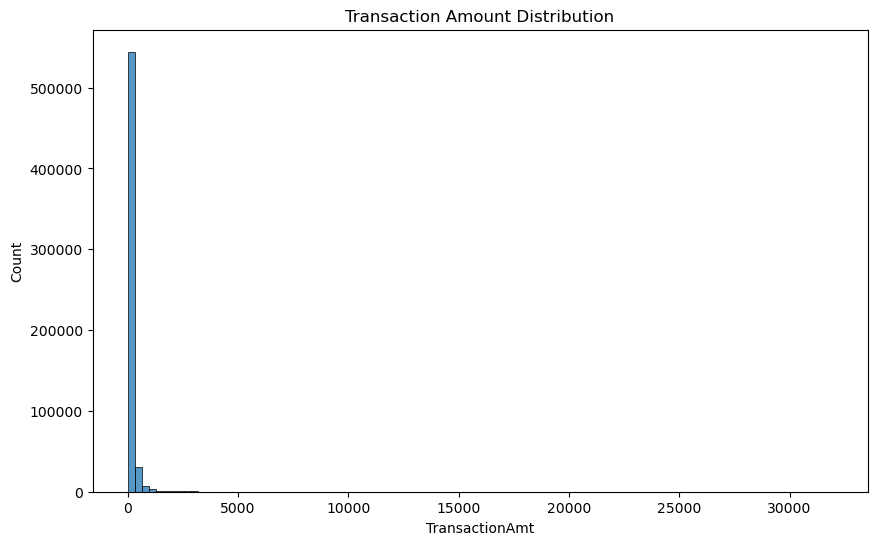

In [200]:
plt.figure(figsize=(10,6))
sns.histplot(train['TransactionAmt'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

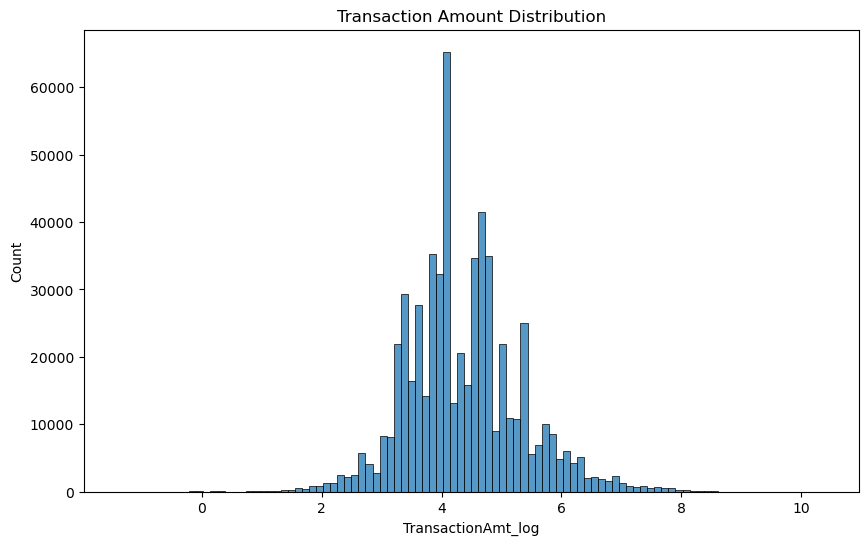

In [201]:
train['TransactionAmt_log']=np.log(train['TransactionAmt'])

plt.figure(figsize=(10,6))
sns.histplot(train['TransactionAmt_log'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

In [202]:
test['TransactionAmt_log']=np.log(test['TransactionAmt'])

# Email match
#### Check email domain between purchaser and recipient are same.

In [207]:
train['match_email']=(train['P_emaildomain']==train['R_emaildomain']).astype(int)
train['match_email']=(test['P_emaildomain']==test['R_emaildomain']).astype(int)

### Email Domain Grouping

In [208]:
email_map = {
    'gmail.com':'google',
    'gmail':'google',
    'yahoo.com':'yahoo',
    'ymail.com':'yahoo',
    'rocketmail.com':'yahoo',
    'hotmail.com':'microsoft',
    "outlook.com": "microsoft",
    "live.com": "microsoft",
    "msn.com": "microsoft",
    "icloud.com": "apple",
    "me.com": "apple",
    "mac.com": "apple",
    "aol.com": "aol",
    "anonymous.com": "anonymous"
}

In [209]:
for col in ['P_emaildomain','R_emaildomain']:
    train[col+"_group"]=train[col].map(email_map).fillna('other')
    test[col+"_group"]=test[col].map(email_map).fillna('other')

### Email Suffix Feature

In [212]:
for col in ['P_emaildomain','R_emaildomain']:
    train[col+'_suffix'] = train[col].astype(str).str.split('.').str[-1]
    test[col+'_suffix'] = test[col].astype(str).str.split('.').str[-1]

for col in ['P_emaildomain_suffix','R_emaildomain_suffix']:
    train[col]=train[col].replace({'nan':'missing'})
    test[col]=test[col].replace({'nan':'missing'})

### Browser Grouping

In [216]:
def group_browser(browser):
    if pd.isna(browser):
        return 'Missing'

    browser=str(browser).lower()

    if 'chrome' in browser:
        return 'chrome'
    elif "firefox" in browser:
        return "Firefox"
    elif "safari" in browser:
        return "Safari"
    elif "edge" in browser:
        return "Edge"
    elif "opera" in browser:
        return "Opera"
    elif "samsung" in browser:
        return "Samsung"
    else:
        return "Others"

    

In [224]:
train['browser_group']=train['id_31'].apply(group_browser)
test['browser_group']=test['id-31'].apply(group_browser)

### Operating System grouping 

In [225]:
def group_os(os):

    if pd.isna(os):
        return "Missing"

    os = str(os).lower()

    if "windows" in os:
        return "Windows"
    elif "ios" in os:
        return "iOS"
    elif "mac" in os:
        return "Mac"
    elif "android" in os:
        return "Android"
    else:
        return "Others"

In [226]:
train['os_group']=train['id_30'].apply(group_os)
test['os_group']=test['id-30'].apply(group_os)

### Transaction Amount Ratio Features

In [232]:
for df in [train, test]:
    df['TransactionAmt_to_mean_card1']=df['TransactionAmt']/df.groupby('card1')['TransactionAmt'].transform('mean')
    df['TransactionAmt_to_std_card1']=df['TransactionAmt']/df.groupby('card1')['TransactionAmt'].transform('std')
    df['TransactionAmt_to_mean_card4']=df['TransactionAmt']/df.groupby('card4')['TransactionAmt'].transform('mean')
    df['TransactionAmt_to_std_card4']=df['TransactionAmt']/df.groupby('card4')['TransactionAmt'].transform('std')

### Missing Indicators

In [240]:
missing_indicator_cols_train = [
    "card2",
    "dist1",
    "dist2",
    "R_emaildomain",
    "DeviceInfo",
    "id_30",
    "id_31"
]


for col in missing_indicator_cols_train:
    train[col+'_missing']=train[col].isnull().astype(int)

In [241]:
missing_indicator_cols_test = [
    "card2",
    "dist1",
    "dist2",
    "R_emaildomain",
    "DeviceInfo",
    "id-30",
    "id-31"
]
for col in missing_indicator_cols_test:
    test[col+'_missing']=test[col].isnull().astype(int)

### Replace Infinite Values

In [243]:
train.replace([np.inf,-np.inf],np.nan,inplace=True)
test.replace([np.inf,-np.inf],np.nan,inplace=True)

### Engineered Features Summary

The following engineered features were created:

#### Transaction Amount Features

* TransactionAmt_log
* TransactionAmt_to_mean_card1
* TransactionAmt_to_std_card1
* TransactionAmt_to_mean_card4
* TransactionAmt_to_std_card4

These features capture transaction behavior relative to historical card-level spending patterns.

#### Email Features

* match_email
* P_emaildomain_group
* R_emaildomain_group
* P_emaildomain_suffix
* R_emaildomain_suffix

These features capture relationships between purchaser and recipient domains while reducing email domain cardinality.

#### Browser and Operating System Features

* browser_group
* os_group

Grouping reduces the number of unique values and improves interpretability.

#### Missing Value Indicators

Missing indicators were created for several features with substantial missingness.

In fraud detection datasets, missingness itself may contain predictive information and therefore should not always be discarded.

The engineered dataset generated in this notebook serves as the foundation for the machine learning models developed in subsequent notebooks.


## Saving Engineered Data

In [245]:
train.to_pickle('../data/train_engineered.pkl')
train.to_pickle('../data/test_engineered.pkl')

# Notebook Conclusion

This notebook focused on exploratory data analysis, statistical validation, and feature engineering for the IEEE-CIS Fraud Detection dataset.

Major findings include:

* The dataset is highly imbalanced, with fraud representing a small percentage of transactions.
* Transaction amount, card-related variables, address features, device information, and email characteristics exhibit meaningful fraud-related patterns.
* Statistical testing confirmed significant associations between fraud and several categorical variables.
* Mutual Information analysis identified multiple features containing predictive signal.
* Feature engineering produced additional variables designed to capture behavioral and transactional relationships.

The final engineered dataset was saved for downstream modeling.

The next notebook focuses on supervised machine learning models, including Logistic Regression, Decision Tree, and Random Forest classifiers for fraud prediction.
